# Thực hành Bài 05 — Dự đoán Monte Carlo và TD(0) trên Lunar Lander

Học tăng cường — Học kỳ 1, năm học 2026–2027

Bài 05 ước lượng giá trị $v_\pi$ của một chính sách cố định chỉ từ dữ liệu tương tác, không dùng mô hình chuyển trạng thái và phần thưởng: Monte Carlo (MC) lấy trung bình các lợi tức quan sát được, còn sai phân thời gian TD(0) cập nhật sau từng chuyển bằng mục tiêu một bước. Notebook này áp dụng hai phương pháp lên môi trường `LunarLander-v3` của thư viện Gymnasium ở chế độ hành động rời rạc, không gió. Bài thực hành của Bài 04 ước lượng mô hình bằng cách gán trạng thái cho bộ mô phỏng rồi lập kế hoạch bằng quy hoạch động; ở đây thuật toán chỉ nhận các lượt đã chạy.

**Mục tiêu học tập.** Sau buổi thực hành, sinh viên có thể:

1. dựng môi trường Lunar Lander, đọc không gian quan sát, hành động, cấu trúc phần thưởng và phân biệt kết thúc với cắt ngắn theo thời gian;
2. đánh giá một chính sách qua nhiều lượt, báo cáo tổng thưởng và lợi tức chiết khấu kèm sai số chuẩn, và trực quan hóa từng lượt;
3. rời rạc hóa quan sát liên tục thành ô, thu tập dữ liệu huấn luyện và kiểm tra theo chính sách cần đánh giá;
4. cài đặt dự đoán MC (lần ghé đầu tiên, mọi lần ghé; trung bình mẫu, bước học hằng) và TD(0) đúng quy trình của Bài 05;
5. so sánh các ước lượng bằng thước đo chỉ dùng dữ liệu, đọc đường học, và giải thích nghiệm của MC và TD trên dữ liệu cố định.

**Tiên quyết.** Bài 03 (MDP, lợi tức chiết khấu, phương trình Bellman kỳ vọng), Bài 04 (đánh giá chính sách, toán tử $T_\pi$, phần dư Bellman) và Bài 05 (MC, TD(0), cập nhật theo lô). Python cơ bản và NumPy.

**Cách dùng.** Chạy các ô theo thứ tự từ trên xuống. Ô cài đặt ở phần 1 tự cài các gói cần thiết, nên notebook chạy được trên Jupyter cục bộ hoặc Google Colab mà không cần tệp nào khác. Mọi phép ngẫu nhiên dùng hạt giống (seed) cố định, nên chạy lại với cùng phiên bản các gói cho cùng số liệu; phiên bản khác có thể cho số liệu lệch. Các ô **Câu hỏi:** có lời giải thu gọn. Trên máy dùng để soạn notebook, toàn bộ các ô chạy dưới hai phút trên CPU, chưa kể thời gian cài gói.

**Ký hiệu** (thống nhất với ghi chú Bài 05):

| Ký hiệu, thuật ngữ | Ý nghĩa trong notebook |
| --- | --- |
| lượt | một episode: từ `reset` tới khi kết thúc thật hoặc bị cắt ngắn ở $1000$ bước |
| $(S_t,A_t,R_{t+1},S_{t+1})$ | mẫu chuyển; $S_t$ là ô của quan sát tại thời điểm $t$ sau rời rạc hóa (phần 4) |
| $\pi$ | chính sách cần đánh giá: bộ điều khiển heuristic của Gymnasium, thay bằng hành động ngẫu nhiên đều với xác suất $\varepsilon=0{,}1$ |
| $\gamma$ | hệ số chiết khấu, dùng $\gamma=0{,}99$ |
| $G_t$ | lợi tức $G_t=\sum_{k=t}^{T-1}\gamma^{k-t}R_{k+1}$, với $G_T=0$ |
| $v_\pi(s)$, $V(s)$ | giá trị thật $\mathbb E_\pi[G_t\mid S_t=s]$ và bảng ước lượng |
| $N(s)$, $\alpha_n(s)$ | số lần cập nhật ô $s$ và bước học ở lần cập nhật thứ $n$ của ô đó |
| $Y_t$, $\delta_t$ | mục tiêu TD $R_{t+1}+\gamma V_t(S_{t+1})$ và sai số TD $Y_t-V_t(S_t)$ |
| $\mathcal D_{\text{huấn luyện}}$, $\mathcal D_{\text{kiểm tra}}$ | hai tập lượt độc lập sinh theo $\pi$; thuật toán chỉ học từ tập huấn luyện |
| $J(V)$ | sai số bình phương trung bình (MSE) của dự đoán lợi tức trên tập kiểm tra, định nghĩa ở phần 8 |
| SE | sai số chuẩn (standard error) của một trung bình mẫu |

## 1. Cài đặt và chuẩn bị

Ô dưới cài Gymnasium kèm phần mở rộng `box2d` (bộ mô phỏng vật lý Box2D cần cho Lunar Lander), NumPy và Matplotlib. Nếu Gymnasium có sẵn cũ hơn bản 1.0 (có thể gặp trên Colab), `pip` nâng cấp lên bản mới; NumPy và Matplotlib đã có thì giữ nguyên bản sẵn có. Nếu môi trường cục bộ đã cài đủ, có thể bỏ qua ô này.

`pip` có thể in dòng *Note: you may need to restart the kernel to use updated packages*. Khi ô cài đặt được chạy trước mọi lệnh `import`, không cần khởi động lại. Nếu trước đó đã `import` một bản cũ của gói vừa được nâng cấp, cần khởi động lại kernel rồi chạy lại notebook từ đầu. Trên Colab, `pip` có thể in cảnh báo xung đột giữa `pygame` và `pygame-ce`; notebook không dùng chức năng hiển thị của Gymnasium (không gọi `render`), nên có thể bỏ qua cảnh báo này.

In [1]:
%pip install -q "gymnasium[box2d]>=1.0" numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import inspect
import time

import numpy as np
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
from gymnasium.envs.box2d import lunar_lander as ll

print("gymnasium", gym.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

T_START = time.time()   # đo tổng thời gian chạy notebook
GAMMA = 0.99            # hệ số chiết khấu
EPS = 0.1               # xác suất chọn hành động ngẫu nhiên trong chính sách pi
EVAL_SEED = 10_000      # hạt giống của các lượt đánh giá ở phần 3
TRAIN_SEED = 20_000     # hạt giống của tập huấn luyện (phần 5)
TEST_SEED = 50_000      # hạt giống của tập kiểm tra (phần 5)

gymnasium 1.3.0 | numpy 2.5.3 | matplotlib 3.11.2


## 2. Môi trường Lunar Lander

**Bài toán.** Một tàu đổ bộ xuất phát ở phía trên, giữa khung hình, chịu một lực đẩy ngẫu nhiên ban đầu và rơi dưới trọng lực. Bãi đáp là đoạn nằm ngang giữa hai lá cờ; địa hình hai bên được sinh ngẫu nhiên ở mỗi lần `reset`. Môi trường được tạo với `continuous=False` (bốn hành động rời rạc) và `enable_wind=False` (không có gió và nhiễu xoắn), trọng lực giữ giá trị mặc định.

**Quan sát** là véc tơ $8$ thành phần, đã chuẩn hóa theo kích thước khung hình:

| chỉ số | biến | ý nghĩa |
| --- | --- | --- |
| 0, 1 | $x$, $y$ | vị trí ngang so với tâm bãi đáp và độ cao so với mức chân chạm bãi |
| 2, 3 | $v_x$, $v_y$ | vận tốc ngang và dọc |
| 4, 5 | $\varphi$, $\omega$ | góc nghiêng của thân tàu và vận tốc góc ($\varphi>0$: quay ngược chiều kim đồng hồ) |
| 6, 7 | $l_1$, $l_2$ | $1$ nếu chân trái, chân phải đang chạm đất; ngược lại $0$ |

Góc được ký hiệu $\varphi$ để tránh trùng với $\theta$ của các bài sau. **Hành động:** $0$ không bật động cơ, $1$ bật động cơ định hướng bên trái, $2$ bật động cơ chính, $3$ bật động cơ định hướng bên phải.

Các thông số in ra được đọc trực tiếp từ đối tượng môi trường.

In [3]:
ENV_ID = "LunarLander-v3"
ENV_KWARGS = dict(continuous=False, enable_wind=False)   # hành động rời rạc, không gió; trọng lực mặc định


def make_env():
    return gym.make(ENV_ID, **ENV_KWARGS)


env = make_env()
core = env.unwrapped                     # đối tượng LunarLander bên trong các lớp bao
obs, _ = env.reset(seed=0)
print("không gian quan sát:", env.observation_space)
print("không gian hành động:", env.action_space)
print("giới hạn số bước mỗi lượt (max_episode_steps):", env.spec.max_episode_steps)
print("trọng lực:", core.gravity, "| gió:", core.enable_wind, "| hành động liên tục:", core.continuous)
print("số bước mô phỏng mỗi giây (FPS):", ll.FPS, "-> mỗi bước dài", 1 / ll.FPS, "giây")
print("quan sát đầu:", obs.round(3))

không gian quan sát: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
không gian hành động: Discrete(4)
giới hạn số bước mỗi lượt (max_episode_steps): 1000
trọng lực: -10.0 | gió: False | hành động liên tục: False
số bước mô phỏng mỗi giây (FPS): 50 -> mỗi bước dài 0.02 giây
quan sát đầu: [ 0.006  1.399  0.578 -0.528 -0.007 -0.131  0.     0.   ]


**Phần thưởng.** Thay vì chỉ dựa vào mô tả, đoạn mã dưới in phần tính thưởng trong hàm `step` của mã nguồn Gymnasium. Gọi

$$\Phi(s)=-100\sqrt{x^2+y^2}-100\sqrt{v_x^2+v_y^2}-100\,\lvert\varphi\rvert+10\,l_1+10\,l_2$$

là hàm `shaping` trong mã. Ở mỗi bước không kết thúc, phần thưởng là độ tăng của $\Phi$ trừ chi phí nhiên liệu:

$$R_{t+1}=\Phi(S_{t+1})-\Phi(S_t)-0{,}3\cdot[A_t=2]-0{,}03\cdot[A_t\in\{1,3\}],$$

với $[\cdot]$ bằng $1$ khi điều kiện đúng. Hàm `reset` kết thúc bằng một lần gọi `step(0)` (không bật động cơ); lần gọi đó ghi $\Phi(S_0)$ vào biến `prev_shaping`, còn phần thưởng của nó không được trả ra ngoài. Vì vậy công thức trên đúng từ bước đầu tiên $t=0$. Ở bước kết thúc, phần thưởng được gán bằng $-100$ nếu thân tàu chạm đất hoặc $\lvert x\rvert\ge1$ (ra khỏi khung hình), và bằng $+100$ nếu thân tàu nằm yên (bộ mô phỏng Box2D chuyển thân tàu sang trạng thái nghỉ). Lượt bị cắt ngắn khi đạt $1000$ bước mà chưa kết thúc.

In [4]:
src = inspect.getsource(ll.LunarLander.step)
start, stop = src.index("shaping = ("), src.index("reward = +100")
print(src[start:stop + len("reward = +100")])
print("...\nDòng cuối của reset():", inspect.getsource(ll.LunarLander.reset).strip().splitlines()[-1].strip())

shaping = (
            -100 * np.sqrt(state[0] * state[0] + state[1] * state[1])
            - 100 * np.sqrt(state[2] * state[2] + state[3] * state[3])
            - 100 * abs(state[4])
            + 10 * state[6]
            + 10 * state[7]
        )  # And ten points for legs contact, the idea is if you
        # lose contact again after landing, you get negative reward
        if self.prev_shaping is not None:
            reward = shaping - self.prev_shaping
        self.prev_shaping = shaping

        reward -= (
            m_power * 0.30
        )  # less fuel spent is better, about -30 for heuristic landing
        reward -= s_power * 0.03

        terminated = False
        if self.game_over or abs(state[0]) >= 1.0:
            terminated = True
            reward = -100
        if not self.lander.awake:
            terminated = True
            reward = +100
...
Dòng cuối của reset(): return self.step(np.array([0, 0]) if self.continuous else 0)[0], {}


Một lượt ngắn với hành động ngẫu nhiên cho vài bước đầu để đọc; trên cùng lượt, mã kiểm tra công thức $R_{t+1}=\Phi(S_{t+1})-\Phi(S_t)-\text{nhiên liệu}$ trên mọi bước $t=0,\dots,T-2$; bước cuối $t=T-1$ có phần thưởng $\pm100$. Quan sát được lưu ở dạng `float32` nên sai lệch cho phép là $10^{-3}$.

In [5]:
def shaping(o):
    # Phi(s) theo mã nguồn; o là quan sát 8 thành phần
    return (-100 * np.hypot(o[0], o[1]) - 100 * np.hypot(o[2], o[3])
            - 100 * abs(o[4]) + 10 * o[6] + 10 * o[7])


def fuel_cost(a):
    # 0,3 cho động cơ chính, 0,03 cho động cơ định hướng
    return 0.3 if a == 2 else (0.03 if a in (1, 3) else 0.0)


rng = np.random.default_rng(1)
o, _ = env.reset(seed=1)
traj = [o]
acts, rews = [], []
done = False
while not done:
    a = int(rng.integers(4))
    o, r, terminated, truncated, _ = env.step(a)
    traj.append(o); acts.append(a); rews.append(r)
    done = terminated or truncated
for t in range(4):
    print(f"t={t}  a={acts[t]}  R_(t+1)={rews[t]:8.3f}  S_(t+1)={traj[t + 1].round(3)}")
print(f"... lượt dài {len(acts)} bước, phần thưởng cuối {rews[-1]}, terminated={terminated}, truncated={truncated}")

# Kiểm tra công thức phần thưởng trên các bước t = 0..T-2; bước cuối t = T-1 nhận ±100
gaps = [abs(rews[t] - (shaping(traj[t + 1]) - shaping(traj[t]) - fuel_cost(acts[t]))) for t in range(len(acts) - 1)]
print("sai lệch lớn nhất giữa phần thưởng và công thức, t = 0..T-2:", f"{max(gaps):.2e}")
assert max(gaps) < 1e-3 and abs(rews[-1]) == 100

t=0  a=1  R_(t+1)=  -0.030  S_(t+1)=[-0.006  1.423 -0.285  0.257  0.008  0.103  0.     0.   ]
t=1  a=2  R_(t+1)=  -2.423  S_(t+1)=[-0.008  1.429 -0.294  0.264  0.013  0.095  0.     0.   ]
t=2  a=3  R_(t+1)=   1.522  S_(t+1)=[-0.011  1.434 -0.285  0.237  0.016  0.059  0.     0.   ]
t=3  a=3  R_(t+1)=   2.057  S_(t+1)=[-0.014  1.439 -0.273  0.211  0.017  0.01   0.     0.   ]
... lượt dài 99 bước, phần thưởng cuối -100, terminated=True, truncated=False
sai lệch lớn nhất giữa phần thưởng và công thức, t = 0..T-2: 3.61e-05


**Hệ quả cho giá trị.** $v_\pi(s)$ là kỳ vọng của phần thưởng **còn lại** sau khi ở $s$. Với $\gamma=1$ và một lượt kết thúc ở thời điểm $T$, tổng các độ tăng $\Phi(S_{k+1})-\Phi(S_k)$ từ $k=t$ tới $k=T-2$ rút gọn, nên

$$G_t=\Phi(S_{T-1})-\Phi(S_t)-\sum_{k=t}^{T-2}c(A_k)+R_T,$$

với $c(A_k)$ là chi phí nhiên liệu và $R_T=\pm100$. Số hạng $-\Phi(S_t)$ làm lợi tức lớn hơn ở trạng thái cao, nhanh, nghiêng hoặc xa bãi đáp, vì $\Phi$ còn nhiều chỗ để tăng. Ba số hạng còn lại cũng phụ thuộc $S_t$ qua phần còn lại của lượt. Do đó giá trị lớn không có nghĩa trạng thái đó tốt hơn để hạ cánh. Với $\gamma=0{,}99$, đẳng thức rút gọn không còn đúng nguyên văn. Khi gộp nhiều quan sát vào một ô ở phần 4, mọi quan sát trong ô nhận chung một giá trị, nên phần biến thiên của $\Phi$ bên trong ô không được biểu diễn.

**Câu hỏi:** Với $\gamma=1$, ô $A$ cao và xa bãi đáp có $V(A)$ lớn hơn ô $B$ ngay trên bãi. Xác định có thể kết luận vị trí $A$ thuận lợi hơn $B$ cho việc hạ cánh hay không, và đề xuất một đại lượng so sánh hai vị trí theo phần thưởng không định hình.

<details><summary>Lời giải</summary>

Không thể kết luận. $V$ đo phần thưởng còn lại, trong đó có phần tăng của $\Phi$ mà $B$ đã nhận phần lớn trước khi tới $B$. Theo đẳng thức trên, $G_t+\Phi(S_t)=\Phi(S_{T-1})-\sum_k c(A_k)+R_T$ chỉ gồm trạng thái cuối, nhiên liệu và kết quả $\pm100$, nên với $\gamma=1$, so sánh $V(s)+\Phi(s)$ của hai vị trí (với $\Phi$ của một quan sát đại diện trong ô) phản ánh triển vọng hạ cánh và chi phí còn lại. Với ô gộp, $\Phi$ thay đổi bên trong ô, nên phép so sánh này chỉ gần đúng.

</details>

## 3. Chính sách cần đánh giá và đánh giá qua nhiều lượt

**Vấn đề.** Dự đoán cần một chính sách $\pi$ cố định. Gymnasium cung cấp một bộ điều khiển viết tay, hàm `heuristic(env, s)` trong mô-đun `gymnasium.envs.box2d.lunar_lander` (đoạn mã chọn hành động rời rạc được in ở ô dưới): hàm tính góc nghiêng mục tiêu hướng về tâm bãi đáp và độ cao mục tiêu theo khoảng cách ngang, rồi bật động cơ chính hoặc một động cơ định hướng theo phần cần hiệu chỉnh lớn hơn. Hàm này tất định. Notebook dùng

$$\pi(a\mid s)=(1-\varepsilon)\,[a=h(s)]+\frac{\varepsilon}{4},\qquad\varepsilon=0{,}1,$$

trong đó $h(s)$ là hành động của bộ điều khiển heuristic. Với xác suất $\varepsilon$, hành động được rút đều trong bốn hành động. Thành phần ngẫu nhiên làm kết quả của các lượt đa dạng hơn: output dưới cho thấy tỉ lệ lượt rơi của $\pi$ cao hơn của heuristic thuần, nên dữ liệu chứa cả lượt nằm yên lẫn lượt rơi. $\pi$ vẫn cố định trong suốt notebook. Hai chính sách đối chứng là heuristic thuần ($\varepsilon=0$) và chính sách ngẫu nhiên đều.

**Đánh giá qua nhiều lượt.** Một lượt chỉ là một mẫu: địa hình, lực đẩy ban đầu, nhiễu của động cơ và các hành động ngẫu nhiên đều thay đổi giữa các lượt. Hàm `evaluate` chạy $N$ lượt với hạt giống `seed + i` cho lượt thứ $i$, dùng cho cả `reset` lẫn bộ sinh số ngẫu nhiên của chính sách, nên ba chính sách gặp cùng dãy địa hình và lực đẩy ban đầu. Với mỗi lượt, hàm ghi tổng thưởng không chiết khấu $\sum_t R_{t+1}$ (thước đo thường dùng cho môi trường này), lợi tức chiết khấu $G_0$ với $\gamma=0{,}99$ (đại lượng mà phần 5–10 dự đoán), độ dài và cách lượt dừng. Trung bình được báo kèm sai số chuẩn $\mathrm{SE}=\mathrm{sd}/\sqrt N$, với sd là độ lệch chuẩn mẫu.

**So sánh theo cặp.** Vì ba chính sách dùng cùng dãy hạt giống, lượt thứ $i$ của hai chính sách $A$, $B$ tạo một cặp. Hàm `paired_difference` tính $d_i=G^A_{0,i}-G^B_{0,i}$ và báo $\bar d\pm1{,}96\,\mathrm{SE}(d)$, như thực hành Bài 04; `evaluate` trả thêm danh sách hạt giống `seeds` để hàm kiểm tra hai kết quả thật sự ghép cặp.

In [6]:
src_h = inspect.getsource(ll.heuristic)
print(src_h[src_h.index("angle_targ = "):])                       # nhánh else: là trường hợp hành động rời rạc

angle_targ = s[0] * 0.5 + s[2] * 1.0  # angle should point towards center
    if angle_targ > 0.4:
        angle_targ = 0.4  # more than 0.4 radians (22 degrees) is bad
    if angle_targ < -0.4:
        angle_targ = -0.4
    hover_targ = 0.55 * np.abs(
        s[0]
    )  # target y should be proportional to horizontal offset

    angle_todo = (angle_targ - s[4]) * 0.5 - (s[5]) * 1.0
    hover_todo = (hover_targ - s[1]) * 0.5 - (s[3]) * 0.5

    if s[6] or s[7]:  # legs have contact
        angle_todo = 0
        hover_todo = (
            -(s[3]) * 0.5
        )  # override to reduce fall speed, that's all we need after contact

    if env.unwrapped.continuous:
        a = np.array([hover_todo * 20 - 1, -angle_todo * 20])
        a = np.clip(a, -1, +1)
    else:
        a = 0
        if hover_todo > np.abs(angle_todo) and hover_todo > 0.05:
            a = 2
        elif angle_todo < -0.05:
            a = 3
        elif angle_todo > +0.05:
            a = 1
    return a



In [7]:
def random_policy(obs, rng):
    return int(rng.integers(4))                       # hành động đều trong {0, 1, 2, 3}


def make_heuristic_policy(env_core, eps):
    def policy(obs, rng):
        if eps > 0 and rng.random() < eps:            # thăm dò: với xác suất eps chọn đều
            return int(rng.integers(4))
        return int(ll.heuristic(env_core, obs))       # còn lại theo bộ điều khiển heuristic h(s)
    return policy


def run_episode(env, policy, seed, keep_terrain=False):
    # Chạy một lượt; lưu quan sát (T+1, 8), hành động (T,), phần thưởng (T,) và cờ dừng
    rng = np.random.default_rng(seed)
    obs, _ = env.reset(seed=seed)
    ep = {"seed": seed}
    if keep_terrain:                                  # địa hình và bãi đáp, chỉ dùng để vẽ
        u = env.unwrapped
        ep["terrain"] = [list(map(float, p[0])) for p in u.sky_polys] + [list(map(float, u.sky_polys[-1][1]))]
        ep["helipad"] = (float(u.helipad_x1), float(u.helipad_x2), float(u.helipad_y))
    states, actions, rewards = [obs], [], []
    while True:
        a = policy(obs, rng)
        obs, r, terminated, truncated, _ = env.step(a)
        states.append(obs); actions.append(a); rewards.append(r)
        if terminated or truncated:
            break
    ep.update(obs=np.array(states), actions=np.array(actions), rewards=np.array(rewards, dtype=float),
              terminated=bool(terminated), truncated=bool(truncated))
    return ep


def outcome(ep):
    # Cách lượt dừng, đọc từ cờ và phần thưởng cuối
    if ep["truncated"]:
        return "cắt ngắn 1000 bước"
    return "nằm yên (+100)" if ep["rewards"][-1] == 100 else "rơi hoặc ra ngoài (-100)"


def discounted_return(rewards, gamma):
    return float(np.sum(rewards * gamma ** np.arange(len(rewards))))   # G_0


def evaluate(env, policy, n_episodes, seed, gamma):
    eps_list = [run_episode(env, policy, seed + i) for i in range(n_episodes)]
    return {"episodes": eps_list, "seeds": [seed + i for i in range(n_episodes)],
            "total": np.array([e["rewards"].sum() for e in eps_list]),               # tổng thưởng không chiết khấu
            "G0": np.array([discounted_return(e["rewards"], gamma) for e in eps_list]),
            "length": np.array([len(e["actions"]) for e in eps_list]),
            "outcome": [outcome(e) for e in eps_list]}


def summarize(name, res):
    n = len(res["total"])
    se = lambda v: v.std(ddof=1) / np.sqrt(n)
    kinds = ["nằm yên (+100)", "rơi hoặc ra ngoài (-100)", "cắt ngắn 1000 bước"]
    frac = "  ".join(f"{k}: {res['outcome'].count(k) / n:4.0%}" for k in kinds)
    print(f"{name:<22} tổng thưởng {res['total'].mean():7.1f} ± {se(res['total']):4.1f} | "
          f"G_0 {res['G0'].mean():6.1f} ± {se(res['G0']):4.1f} | dài {res['length'].mean():5.0f} bước | {frac}")


N_EVAL = 100
policies = {"ngẫu nhiên": random_policy,
            "heuristic (ε = 0)": make_heuristic_policy(core, 0.0),
            "π (ε = 0,1)": make_heuristic_policy(core, EPS)}
t0 = time.time()
results = {name: evaluate(env, p, N_EVAL, EVAL_SEED, GAMMA) for name, p in policies.items()}
print(f"{N_EVAL} lượt mỗi chính sách, cùng tập hạt giống; trung bình ± SE ({time.time() - t0:.1f} giây)")
for name, res in results.items():
    summarize(name, res)


def paired_difference(res_a, res_b, key="G0"):
    # Hiệu theo cặp d_i = res_a[key][i] - res_b[key][i] trên cùng hạt giống; trả trung bình và 1,96 * SE
    assert res_a["seeds"] == res_b["seeds"]
    d = res_a[key] - res_b[key]
    return d.mean(), 1.96 * d.std(ddof=1) / np.sqrt(len(d))


for key, label in [("total", "tổng thưởng"), ("G0", "G_0")]:
    m, h = paired_difference(results["heuristic (ε = 0)"], results["π (ε = 0,1)"], key)
    print(f"heuristic - π, {label}: {m:6.1f} ± {h:4.1f} (khoảng 95%, ghép cặp)")

100 lượt mỗi chính sách, cùng tập hạt giống; trung bình ± SE (3.9 giây)
ngẫu nhiên             tổng thưởng  -187.4 ± 10.7 | G_0  -93.6 ±  5.0 | dài    91 bước | nằm yên (+100):   0%  rơi hoặc ra ngoài (-100): 100%  cắt ngắn 1000 bước:   0%
heuristic (ε = 0)      tổng thưởng   255.4 ±  7.5 | G_0   72.9 ±  2.2 | dài   249 bước | nằm yên (+100):  96%  rơi hoặc ra ngoài (-100):   3%  cắt ngắn 1000 bước:   1%
π (ε = 0,1)            tổng thưởng   213.6 ± 12.5 | G_0   61.6 ±  2.9 | dài   294 bước | nằm yên (+100):  79%  rơi hoặc ra ngoài (-100):  18%  cắt ngắn 1000 bước:   3%
heuristic - π, tổng thưởng:   41.9 ± 22.9 (khoảng 95%, ghép cặp)
heuristic - π, G_0:   11.3 ±  4.3 (khoảng 95%, ghép cặp)


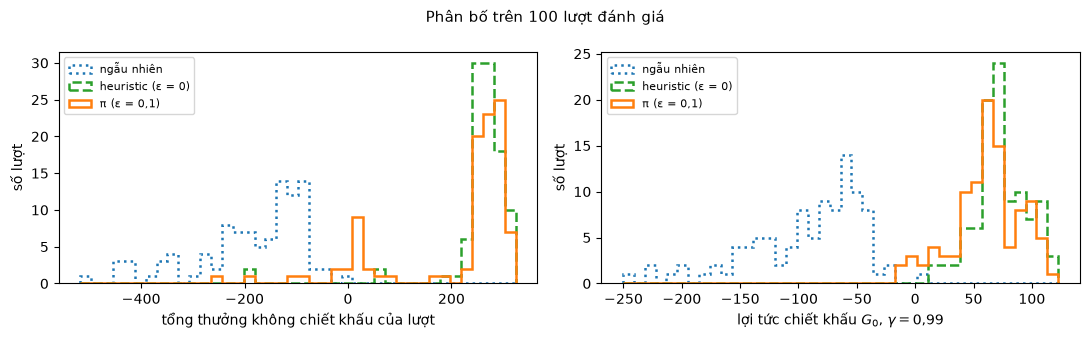

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
line_styles = [":", "--", "-"]                                   # phân biệt chính sách bằng kiểu nét, như mục 3.1
colors = ["C0", "C2", "C1"]
for ax, key in zip(axes, ["total", "G0"]):
    allv = np.concatenate([res[key] for res in results.values()])
    bins = np.linspace(allv.min(), allv.max(), 41)                 # chung một bộ khoảng cho ba chính sách
    for (name, res), ls, col in zip(results.items(), line_styles, colors):
        ax.hist(res[key], bins=bins, histtype="step", linestyle=ls, color=col, linewidth=1.8, label=name)
axes[0].set_xlabel("tổng thưởng không chiết khấu của lượt")
axes[1].set_xlabel(r"lợi tức chiết khấu $G_0$, $\gamma=0{,}99$")
for ax in axes:
    ax.set_ylabel("số lượt")
    ax.legend(fontsize=8)
fig.suptitle(f"Phân bố trên {N_EVAL} lượt đánh giá", fontsize=11)
plt.tight_layout()
plt.show()

**Chọn $\gamma$ và xử lý cắt ngắn.** Mỗi bước dài $0{,}02$ giây. Với $\gamma=0{,}99$, trọng số $\gamma^k$ còn khoảng $e^{-1}\approx0{,}37$ sau $1/(1-\gamma)=100$ bước, tức $2$ giây mô phỏng, rồi tiếp tục giảm theo cấp số nhân; phần thưởng $\pm100$ ở bước kết thúc của một lượt dài vài trăm bước vì thế đóng góp ít vào $G_0$ so với tổng không chiết khấu. Bài 05 phát biểu MC cho lượt kết thúc thật. Lượt bị cắt ngắn không có lợi tức đầy đủ, nên phần 6 bỏ các lượt này khỏi MC, còn TD(0) ở phần 7 vẫn dùng được các chuyển của chúng; output trên cho biết tỉ lệ cắt ngắn của từng chính sách.

**Câu hỏi:** Từ output, ước lượng khoảng tin cậy xấp xỉ $95\%$ của $\mathbb E_\pi[G_0]$ với $N=100$ lượt. Giải thích vì sao tổng thưởng của một lượt duy nhất không đủ để so sánh hai chính sách.

<details><summary>Lời giải</summary>

Khoảng xấp xỉ là trung bình $\pm1{,}96\,\mathrm{SE}$ của cột $G_0$ ứng với $\pi$. Một lượt là một mẫu của biến ngẫu nhiên tổng thưởng: địa hình, lực đẩy ban đầu, nhiễu động cơ và các hành động ngẫu nhiên đều đổi theo lượt. Với $N=100$, độ lệch chuẩn giữa các lượt bằng $10$ lần SE; theo output, độ lệch chuẩn của $G_0$ dưới $\pi$ lớn hơn chênh lệch giữa trung bình $G_0$ của heuristic thuần và của $\pi$, nên một lượt của mỗi chính sách có thể cho thứ tự ngược với thứ tự của hai trung bình. Hiệu theo cặp in ở trên dùng cả $100$ cặp lượt nên có khoảng tin cậy hẹp hơn. Phần 5 dùng $500$ lượt kiểm tra để ước lượng $\mathbb E_\pi[G_0]$ với SE nhỏ hơn.

</details>

### 3.1. Trực quan hóa một lượt

Phần này ghi lại một lượt của mỗi chính sách đã đánh giá ở trên (ngẫu nhiên, heuristic thuần và $\pi$) trên cùng hạt giống, nên ba lượt có cùng địa hình và cùng lực đẩy ban đầu. Hạt giống minh họa được chọn tự động là hạt giống đầu tiên trong tập đánh giá mà lượt của $\pi$ kết thúc bằng nằm yên; đoạn mã kiểm tra lại rằng lượt ghi lại trùng độ dài với lượt tương ứng trong phép đánh giá.

**Tọa độ vẽ.** Quan sát đã chuẩn hóa được đổi về tọa độ của bộ mô phỏng (mét) theo đúng công thức trong `step`:

$$x_w=\frac W2\,(x+1),\qquad y_w=\frac H2\,y+y_{\text{bãi}}+\frac{\texttt{LEG\_DOWN}}{\texttt{SCALE}},$$

với $W\times H$ là kích thước khung hình ($20\times13{,}3$ m) và $y_{\text{bãi}}$ là độ cao bãi đáp. Thân tàu là đa giác `LANDER_POLY` của mã nguồn, quay góc $\varphi$; hai chân được vẽ gần đúng.

In [9]:
W_WORLD = ll.VIEWPORT_W / ll.SCALE      # bề rộng khung hình (m)
H_WORLD = ll.VIEWPORT_H / ll.SCALE      # chiều cao khung hình (m)
LANDER_POLY = np.array(ll.LANDER_POLY, dtype=float) / ll.SCALE   # đa giác thân tàu trong hệ tọa độ thân (m)


def to_world(obs, helipad_y):
    # Quan sát chuẩn hóa -> tọa độ (m) của tâm thân tàu, theo công thức trong step()
    xw = obs[..., 0] * (W_WORLD / 2) + W_WORLD / 2
    yw = obs[..., 1] * (H_WORLD / 2) + helipad_y + ll.LEG_DOWN / ll.SCALE
    return xw, yw


def lander_outline(xw, yw, phi):
    # Đa giác thân tàu sau khi quay góc phi (ngược chiều kim đồng hồ) và tịnh tiến tới (xw, yw)
    c, s = np.cos(phi), np.sin(phi)
    px, py = LANDER_POLY[:, 0], LANDER_POLY[:, 1]
    return np.c_[xw + c * px - s * py, yw + s * px + c * py]


# Chọn hạt giống minh họa: lượt đầu tiên trong tập đánh giá mà pi kết thúc bằng nằm yên
k_viz = next(i for i, oc in enumerate(results["π (ε = 0,1)"]["outcome"]) if oc == "nằm yên (+100)")
VIZ_SEED = EVAL_SEED + k_viz
episodes_ref = {name: run_episode(env, policies[name], VIZ_SEED, keep_terrain=True)
                for name in policies}
for name, ep in episodes_ref.items():
    assert len(ep["actions"]) == results[name]["length"][k_viz]      # trùng lượt trong phép đánh giá
    print(f"{name:<18} hạt giống {VIZ_SEED}: {len(ep['actions'])} bước, {outcome(ep)}, "
          f"tổng thưởng {ep['rewards'].sum():.1f}")
ep_pi = episodes_ref["π (ε = 0,1)"]
n_diff = sum(int(a != ll.heuristic(core, o)) for o, a in zip(ep_pi["obs"][:-1], ep_pi["actions"]))
print(f"số bước mà π chọn hành động khác h(S_t) trong lượt của π: {n_diff}/{len(ep_pi['actions'])}")

ngẫu nhiên         hạt giống 10000: 66 bước, rơi hoặc ra ngoài (-100), tổng thưởng -129.9
heuristic (ε = 0)  hạt giống 10000: 190 bước, nằm yên (+100), tổng thưởng 253.3
π (ε = 0,1)        hạt giống 10000: 216 bước, nằm yên (+100), tổng thưởng 278.0
số bước mà π chọn hành động khác h(S_t) trong lượt của π: 14/216


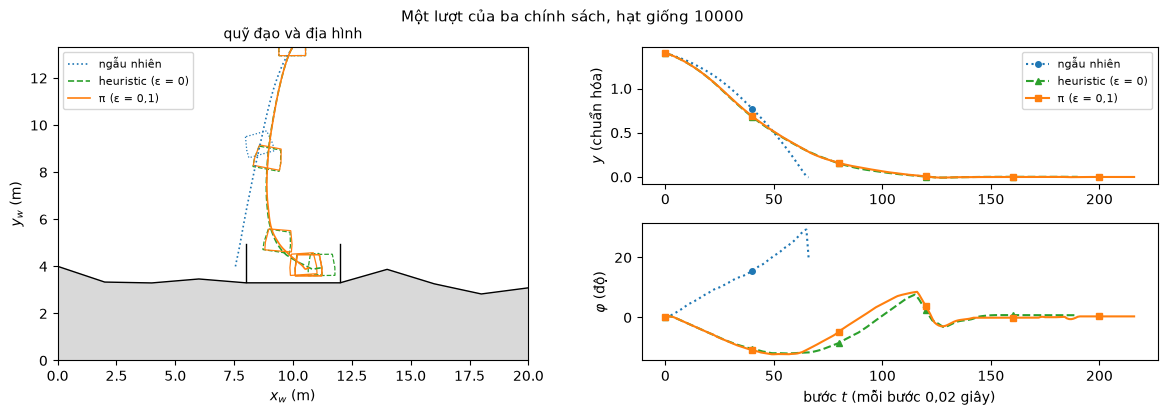

In [10]:
STYLES = {"ngẫu nhiên": dict(ls=":", marker="o", color="C0"),           # kiểu nét và dấu phân biệt chính sách
          "heuristic (ε = 0)": dict(ls="--", marker="^", color="C2"),
          "π (ε = 0,1)": dict(ls="-", marker="s", color="C1")}


def plot_episodes(episodes, styles, title, every=40):
    # Trái: quỹ đạo trong mặt phẳng, kèm địa hình và hình thân tàu mỗi `every` bước; phải: y(t) và góc phi(t)
    fig = plt.figure(figsize=(12, 4.2))
    ax0 = fig.add_subplot(1, 2, 1)
    ax1 = fig.add_subplot(2, 2, 2)
    ax2 = fig.add_subplot(2, 2, 4, sharex=ax1)
    first = next(iter(episodes.values()))
    terr = np.array(first["terrain"])
    x1, x2, hy = first["helipad"]
    ax0.fill_between(terr[:, 0], 0, terr[:, 1], color="0.85")
    ax0.plot(terr[:, 0], terr[:, 1], color="k", lw=1)
    for xf in (x1, x2):                                             # hai cờ của bãi đáp
        ax0.plot([xf, xf], [hy, hy + 1.6], color="k", lw=1)
    for name, ep in episodes.items():
        st = styles[name]
        xw, yw = to_world(ep["obs"], hy)
        t = np.arange(len(xw))
        ax0.plot(xw, yw, ls=st["ls"], color=st["color"], lw=1.2, label=name)
        for k in range(0, len(xw), every):                          # hình thân tàu tại một số thời điểm
            ax0.add_patch(plt.Polygon(lander_outline(xw[k], yw[k], ep["obs"][k, 4]), fill=False, ls=st["ls"],
                                      ec=st["color"], lw=0.9))
        ax1.plot(t, ep["obs"][:, 1], ls=st["ls"], color=st["color"], marker=st["marker"], markevery=every, ms=4, label=name)
        ax2.plot(t, np.degrees(ep["obs"][:, 4]), ls=st["ls"], color=st["color"], marker=st["marker"], markevery=every, ms=4)
    ax0.set_xlim(0, W_WORLD); ax0.set_ylim(0, H_WORLD); ax0.set_aspect("equal")
    ax0.set_xlabel("$x_w$ (m)"); ax0.set_ylabel("$y_w$ (m)"); ax0.legend(fontsize=8, loc="upper left")
    ax0.set_title("quỹ đạo và địa hình", fontsize=10)
    ax1.set_ylabel("$y$ (chuẩn hóa)"); ax1.legend(fontsize=8)
    ax2.set_ylabel(r"$\varphi$ (độ)"); ax2.set_xlabel("bước $t$ (mỗi bước 0,02 giây)")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_episodes(episodes_ref, STYLES, f"Một lượt của ba chính sách, hạt giống {VIZ_SEED}")

**Hoạt hình.** Trình phát dưới vẽ trên phần tử `<canvas>` của trình duyệt từ mảng quan sát đã ghi; dữ liệu nhúng cỡ vài chục kilobyte. Mỗi lượt có một ô: địa hình màu xám, hai cờ bãi đáp, đường chấm là quãng đường đã đi, thân tàu quay theo $\varphi$; ngọn lửa vẽ ở động cơ đang bật (dưới thân với hành động $2$, bên phải thân với hành động $1$, bên trái thân với hành động $3$), và dòng trạng thái ghi tên hành động, nên hình đọc được cả khi không phân biệt màu. Chân đang chạm đất được tô đặc. Ô của lượt đã dừng giữ khung cuối và ghi lý do dừng.

Ba ô xếp cạnh nhau và xuống dòng khi khung hiển thị hẹp. Nút **Phát/Dừng**, thanh trượt và ô chọn tốc độ điều khiển việc phát; ở tốc độ $1\times$, mỗi bước $0{,}02$ giây được phát trong $20$ mili giây. Hàm Python `lander_player` chỉ đóng gói dữ liệu thành JSON và chèn vào một mẫu HTML có đoạn JavaScript vẽ hình. Không cần đọc mã JavaScript; chỉ cần biết `lander_player(episodes, info=None)` nhận một từ điển `{tên: lượt}` gồm các lượt do `run_episode(..., keep_terrain=True)` trả về, và tùy chọn `info` là các dãy số in dưới tiêu đề (dùng ở mục 10.3). Trình phát cần JavaScript, chạy được trong các giao diện cho phép JavaScript trong output như Jupyter, JupyterLab, VS Code hay Colab (khi soạn notebook mới kiểm trên trình duyệt Chromium); nếu notebook mở ở chế độ chưa tin cậy hoặc trên trang xem tĩnh, ô hiện dòng báo cần chạy lại ô. Hình tĩnh ở trên hiển thị được trong mọi trường hợp.

In [11]:
import hashlib
import json
from IPython.display import HTML, display

ACTION_NAMES = ["không bật động cơ", "động cơ định hướng trái (a=1)", "động cơ chính (a=2)",
                "động cơ định hướng phải (a=3)"]

# Mẫu HTML của trình phát; __ID__ và __DATA__ được thay bằng mã ô và dữ liệu JSON
PLAYER_HTML = '''
<div id="__ID__" style="font-family: sans-serif; font-size: 13px;">
  <div class="lp-nojs" style="color: #a00;">Trình phát cần JavaScript: tin cậy notebook hoặc chạy lại ô này.</div>
  <div class="lp-panels" style="display: flex; flex-wrap: wrap; gap: 8px;"></div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 6px; max-width: 856px;">
    <button class="lp-play" style="font-size: 13px;">Phát</button>
    <input class="lp-slider" type="range" min="0" value="0" style="flex: 1;">
    <span class="lp-label" style="min-width: 150px;"></span>
    <select class="lp-speed" style="font-size: 13px;">
      <option value="0.25">0,25×</option><option value="0.5">0,5×</option>
      <option value="1" selected>1× (thời gian thực)</option>
    </select>
  </div>
</div>
<script>
(function () {
  const root = document.getElementById('__ID__');
  const D = __DATA__;                                   // hằng số hình học và các lượt
  root.querySelector('.lp-nojs').style.display = 'none';
  const W = 420, TOP = D.info ? 58 : 40;                 // bề rộng ô (px); TOP: phần chữ phía trên
  const s = W / D.world_w;                               // số px trên một mét
  const H = TOP + Math.round(D.world_h * s);             // chiều cao ô (px)
  const dpr = window.devicePixelRatio || 1;              // vẽ sắc nét trên màn hình mật độ cao
  function SX(x) { return x * s; }                       // tọa độ (m) -> px
  function SY(y) { return TOP + (D.world_h - y) * s; }
  const ctxs = D.episodes.map(function () {
    const c = document.createElement('canvas');
    c.width = W * dpr; c.height = H * dpr;
    c.style.width = W + 'px'; c.style.maxWidth = '100%'; c.style.border = '1px solid #ddd';
    root.querySelector('.lp-panels').appendChild(c);
    const ctx = c.getContext('2d'); ctx.scale(dpr, dpr);
    return ctx;
  });
  const Tmax = Math.max.apply(null, D.episodes.map(function (e) { return e.T; }));
  const slider = root.querySelector('.lp-slider'), label = root.querySelector('.lp-label');
  const btn = root.querySelector('.lp-play'), speed = root.querySelector('.lp-speed');
  slider.max = Tmax;

  function body(ctx, x, y, phi, pts) {                   // vẽ đa giác trong hệ tọa độ thân tàu
    const c = Math.cos(phi), sn = Math.sin(phi);
    ctx.beginPath();
    pts.forEach(function (p, i) {
      const X = SX(x + c * p[0] - sn * p[1]), Y = SY(y + sn * p[0] + c * p[1]);
      if (i === 0) ctx.moveTo(X, Y); else ctx.lineTo(X, Y);
    });
    ctx.closePath();
  }

  function draw(ctx, ep, t) {
    const k = Math.min(t, ep.T);                         // lượt đã dừng giữ khung cuối
    ctx.clearRect(0, 0, W, H);
    ctx.fillStyle = '#000'; ctx.textAlign = 'center';
    ctx.font = 'bold 14px sans-serif'; ctx.fillText(ep.name, W / 2, 15);
    ctx.font = '13px sans-serif';
    ctx.fillText(t < ep.T ? 'bước ' + k + ' (' + (k * D.dt).toFixed(2) + ' s): ' + D.action_names[ep.a[k]]
                          : 'kết thúc ở bước ' + ep.T + ': ' + ep.reason, W / 2, 32);
    if (D.info) {                                        // dòng số liệu tùy chọn (phần 10)
      const vals = ep.info.map(function (col) { return col[Math.min(k, col.length - 1)]; });
      ctx.fillText(D.info.map(function (n, i) { return n + ' = ' + vals[i].toFixed(1); }).join('   '), W / 2, 50);
    }
    ctx.beginPath(); ctx.moveTo(SX(ep.terrain[0][0]), SY(0));                     // địa hình
    ep.terrain.forEach(function (p) { ctx.lineTo(SX(p[0]), SY(p[1])); });
    ctx.lineTo(SX(ep.terrain[ep.terrain.length - 1][0]), SY(0)); ctx.closePath();
    ctx.fillStyle = '#d9d9d9'; ctx.fill(); ctx.strokeStyle = '#555'; ctx.lineWidth = 1; ctx.stroke();
    [ep.pad[0], ep.pad[1]].forEach(function (xf) {                                // cờ bãi đáp
      ctx.strokeStyle = '#000'; ctx.beginPath();
      ctx.moveTo(SX(xf), SY(ep.pad[2])); ctx.lineTo(SX(xf), SY(ep.pad[2] + 1.6)); ctx.stroke();
      ctx.fillStyle = '#e6c229'; ctx.beginPath(); ctx.moveTo(SX(xf), SY(ep.pad[2] + 1.6));
      ctx.lineTo(SX(xf), SY(ep.pad[2] + 1.2)); ctx.lineTo(SX(xf) + 10, SY(ep.pad[2] + 1.4)); ctx.closePath(); ctx.fill();
    });
    ctx.setLineDash([2, 3]); ctx.strokeStyle = '#4c72b0'; ctx.beginPath();        // quãng đường đã đi
    for (let i = 0; i <= k; i++) { if (i === 0) ctx.moveTo(SX(ep.x[i]), SY(ep.y[i])); else ctx.lineTo(SX(ep.x[i]), SY(ep.y[i])); }
    ctx.stroke(); ctx.setLineDash([]);
    const x = ep.x[k], y = ep.y[k], phi = ep.phi[k];
    if (t < ep.T) {                                      // ngọn lửa ở động cơ đang bật
      const a = ep.a[k];
      const flames = {2: [[-0.2, -0.33], [0.2, -0.33], [0, -1.0]],
                      1: [[0.57, 0.15], [0.57, 0.4], [1.05, 0.27]],
                      3: [[-0.57, 0.15], [-0.57, 0.4], [-1.05, 0.27]]};
      if (flames[a]) { body(ctx, x, y, phi, flames[a]); ctx.fillStyle = '#f28e2b'; ctx.fill();
                       ctx.strokeStyle = '#7f2704'; ctx.lineWidth = 1; ctx.stroke(); }
    }
    [-1, 1].forEach(function (sg, i) {                    // chân: tô đặc khi chạm đất
      const c = Math.cos(phi), sn = Math.sin(phi);
      const p0 = [sg * 0.4, -0.3], p1 = [sg * 0.7, -0.6];
      ctx.strokeStyle = '#000'; ctx.lineWidth = 2; ctx.beginPath();
      ctx.moveTo(SX(x + c * p0[0] - sn * p0[1]), SY(y + sn * p0[0] + c * p0[1]));
      const fx = SX(x + c * p1[0] - sn * p1[1]), fy = SY(y + sn * p1[0] + c * p1[1]);
      ctx.lineTo(fx, fy); ctx.stroke();
      ctx.beginPath(); ctx.arc(fx, fy, 3.5, 0, 2 * Math.PI);
      const touch = (i === 0 ? ep.l1[k] : ep.l2[k]) > 0.5;
      ctx.fillStyle = touch ? '#000' : '#fff'; ctx.fill(); ctx.stroke();
    });
    body(ctx, x, y, phi, D.poly);                        // thân tàu
    ctx.fillStyle = '#c6dbef'; ctx.fill(); ctx.strokeStyle = '#000'; ctx.lineWidth = 1.2; ctx.stroke();
  }

  let t = 0, timer = null;
  function render() {
    slider.value = t;
    label.textContent = 'bước ' + t + ' / ' + Tmax + ' (' + (t * D.dt).toFixed(2) + ' s)';
    D.episodes.forEach(function (ep, i) { draw(ctxs[i], ep, t); });
  }
  function stop() { clearInterval(timer); timer = null; btn.textContent = 'Phát'; }
  function start() {
    if (t >= Tmax) t = 0;
    btn.textContent = 'Dừng';
    // mỗi bước dt giây được phát trong dt / tốc độ giây
    timer = setInterval(function () { t += 1; render(); if (t >= Tmax) stop(); },
                        1000 * D.dt / parseFloat(speed.value));
  }
  btn.onclick = function () { if (timer) stop(); else start(); };
  speed.onchange = function () { if (timer) { stop(); start(); } };
  slider.oninput = function () { if (timer) stop(); t = parseInt(slider.value, 10); render(); };
  render();
})();
</script>
'''

PLAYER_COUNT = [0]


def lander_player(episodes, info=None):
    # Đóng gói các lượt thành JSON. info (tùy chọn): {tên: {tên lượt: mảng giá trị theo bước}} để in dưới tiêu đề
    eps_json = []
    for name, ep in episodes.items():
        xw, yw = to_world(ep["obs"], ep["helipad"][2])
        item = {"name": name, "T": len(ep["actions"]), "reason": outcome(ep),
                "x": xw.astype(float).round(3).tolist(), "y": yw.astype(float).round(3).tolist(),   # (T+1,)
                "phi": ep["obs"][:, 4].astype(float).round(3).tolist(),                             # (T+1,)
                "l1": ep["obs"][:, 6].astype(int).tolist(), "l2": ep["obs"][:, 7].astype(int).tolist(),
                "a": ep["actions"].astype(int).tolist(),                                            # (T,)
                "terrain": np.round(ep["terrain"], 3).tolist(), "pad": list(ep["helipad"])}
        if info:
            item["info"] = [np.asarray(info[k][name], dtype=float).round(2).tolist() for k in info]
        eps_json.append(item)
    data = {"world_w": W_WORLD, "world_h": H_WORLD, "dt": 1 / ll.FPS, "poly": LANDER_POLY.round(4).tolist(),
            "action_names": ACTION_NAMES, "info": list(info) if info else None, "episodes": eps_json}
    payload = json.dumps(data, ensure_ascii=False)
    PLAYER_COUNT[0] += 1                                           # mỗi lần hiển thị một mã riêng
    uid = f"lp{PLAYER_COUNT[0]}_" + hashlib.md5(payload.encode()).hexdigest()[:10]   # tất định giữa các lần chạy
    html = PLAYER_HTML.replace("__ID__", uid).replace("__DATA__", payload)
    print(f"Trình phát: {len(episodes)} lượt, dài nhất {max(len(e['actions']) for e in episodes.values())} bước; "
          f"HTML nhúng {len(html) / 1e3:.0f} kB")
    return html


display(HTML(lander_player(episodes_ref)))

Trình phát: 3 lượt, dài nhất 216 bước; HTML nhúng 23 kB


Chính sách ngẫu nhiên bật các động cơ không theo trạng thái; trong lượt minh họa, đồ thị $\varphi(t)$ cho thấy góc nghiêng lớn dần cho tới khi tàu va chạm. Heuristic thuần và $\pi$ giữ góc nghiêng nhỏ và hạ độ cao dần về bãi đáp. Ba lượt dùng chung địa hình và lực đẩy ban đầu, nên khác biệt giữa chúng đến từ chính sách và từ nhiễu của động cơ trong quá trình chạy. Khác biệt giữa heuristic thuần và $\pi$ chỉ đến từ các bước $\pi$ chọn hành động khác $h(S_t)$; output in số bước đó cùng độ dài và kết quả của hai lượt. Trên $100$ lượt, ảnh hưởng của các bước này thể hiện ở tỉ lệ rơi và hiệu theo cặp đã in ở phần 3.

## 4. Biểu diễn bảng: rời rạc hóa quan sát

**Vấn đề.** Các quy trình MC và TD(0) của Bài 05 lưu một số $V(s)$ cho mỗi trạng thái trong tập hữu hạn $\mathcal S$. Quan sát Lunar Lander có sáu thành phần thực và hai thành phần nhị phân, nên cần ánh xạ quan sát về một tập ô hữu hạn, như đã làm với CartPole ở thực hành Bài 04.

**Trực giác.** Chia trục của mỗi biến liên tục thành vài khoảng; hai biến chân được gộp thành số chân đang chạm đất $l_1+l_2\in\{0,1,2\}$. Mỗi tổ hợp chỉ số là một ô. Mọi quan sát trong cùng ô dùng chung một giá trị, nên ô có thể gộp các trạng thái có lợi tức kỳ vọng khác nhau. Ghi chú Bài 05 giả thiết trạng thái chứa đủ thông tin Markov; ô gộp nói chung không thỏa giả thiết này, và phần 9 cho thấy hệ quả.

Để chọn điểm cắt, đoạn mã dưới tính phân vị của từng biến trên các quan sát của $\pi$ trong $100$ lượt đánh giá ở phần 3.

In [12]:
obs_pi = np.concatenate([e["obs"] for e in results["π (ε = 0,1)"]["episodes"]])   # (số quan sát, 8)
VAR_NAMES = ["x", "y", "v_x", "v_y", "phi", "omega", "l_1", "l_2"]
qs = [0.5, 5, 25, 50, 75, 95, 99.5]
print(f"{len(obs_pi)} quan sát của pi")
print("phân vị  " + "".join(f"{q:>8}%" for q in qs))
for j, name in enumerate(VAR_NAMES[:6]):
    print(f"{name:<8}" + "".join(f"{v:9.3f}" for v in np.percentile(obs_pi[:, j], qs)))
print("tỉ lệ quan sát có ít nhất một chân chạm đất:", f"{np.mean(obs_pi[:, 6] + obs_pi[:, 7] > 0):.2f}")

29461 quan sát của pi
phân vị       0.5%       5%      25%      50%      75%      95%    99.5%
x          -0.563   -0.335   -0.109   -0.001    0.106    0.388    0.635
y          -0.130   -0.048   -0.001    0.007    0.366    1.373    1.479
v_x        -0.751   -0.520   -0.135    0.000    0.141    0.519    0.726
v_y        -1.033   -0.897   -0.435   -0.026    0.000    0.051    0.243
phi        -0.410   -0.277   -0.045    0.000    0.072    0.330    0.508
omega      -0.724   -0.173   -0.044    0.000    0.046    0.176    0.642
tỉ lệ quan sát có ít nhất một chân chạm đất: 0.45


**Chọn điểm cắt.** Mỗi biến liên tục $j$ có các điểm cắt $c_{j,1}<\dots<c_{j,m_j}$ (`CUTS[j]`), chia trục thành $m_j+1$ khoảng.

- $x$: điểm cắt tại hai mép bãi đáp. Bãi đáp nằm giữa hai cờ $x_w\in[8;12]$ m, ứng với $x=\pm0{,}2$ sau chuẩn hóa (đoạn mã tính lại từ môi trường); ba khoảng là bên trái bãi, trên bãi, bên phải bãi.
- $y$: điểm cắt $0{,}1;\ 0{,}4;\ 0{,}8$, tách vùng sát mặt đất, độ cao thấp, trung bình và vùng xuất phát (tàu bắt đầu ở $y\approx1{,}4$).
- $v_x$: điểm cắt $-0{,}2;\ 0;\ 0{,}2$, tách hướng và độ lớn của chuyển động ngang.
- $v_y$: điểm cắt $-0{,}5;\ -0{,}2;\ -0{,}05$; phần lớn quan sát có $v_y\le0$ (đang rơi), nên các khoảng tập trung ở phía âm.
- $\varphi$ và $\omega$: điểm cắt $-0{,}1;\ 0;\ 0{,}1$ rad và $-0{,}05;\ 0;\ 0{,}05$, tách dấu và độ lớn của góc nghiêng và vận tốc góc.

Số ô là $3\cdot4\cdot4\cdot4\cdot4\cdot4\cdot3=9216$. Mã kiểm tra mọi điểm cắt nằm giữa phân vị $5\%$ và $95\%$ ở trên, nên khoảng nào cũng có dữ liệu. **Công khai về cách chọn:** khi soạn notebook, vài cách chia (theo ý nghĩa vật lý như trên, theo phân vị, thô hơn và mịn hơn) được so sánh sơ bộ bằng sai số dự đoán của MC theo lô, dùng cùng tập huấn luyện và tập kiểm tra như phần 5. Vì việc chọn có nhìn vào tập kiểm tra, sai số kiểm tra của cách chia được giữ lại có thể thấp hơn một chút so với trên dữ liệu mới; cách chia này cũng không tối ưu theo một tiêu chuẩn nào. Phần 12 gợi ý các cách chia khác.

**Phép gán ô.** Chỉ số khoảng của giá trị $v$ là số điểm cắt nhỏ hơn hoặc bằng $v$, $b_j=\#\{k:c_{j,k}\le v\}$, nên giá trị ngoài các điểm cắt rơi vào khoảng đầu hoặc khoảng cuối. Chỉ số ô ghép bảy chỉ số theo thứ tự hàng (chỉ số cuối là số chân chạm đất, thay đổi nhanh nhất); `np.searchsorted(c, v, side="right")` tính $b_j$ và `np.ravel_multi_index` tính chỉ số ô.

In [13]:
X_PAD = (core.helipad_x2 - W_WORLD / 2) / (W_WORLD / 2)        # mép phải bãi đáp sau chuẩn hóa
print("mép bãi đáp sau chuẩn hóa: x = ±", X_PAD)

CUTS = [
    np.array([-X_PAD, X_PAD]),           # x: trái bãi | trên bãi | phải bãi
    np.array([0.1, 0.4, 0.8]),           # y: 4 khoảng độ cao
    np.array([-0.2, 0.0, 0.2]),          # v_x: 4 khoảng
    np.array([-0.5, -0.2, -0.05]),       # v_y: 4 khoảng, tập trung phía rơi xuống
    np.array([-0.1, 0.0, 0.1]),          # phi (rad): 4 khoảng
    np.array([-0.05, 0.0, 0.05]),        # omega: 4 khoảng
]


def grid_shape(cuts):
    return tuple(len(c) + 1 for c in cuts) + (3,)          # thêm trục số chân chạm đất 0, 1, 2


def discretize(obs, cuts):
    # obs: mảng (..., 8) -> chỉ số ô cùng hình dạng (...)
    obs = np.asarray(obs)
    idx = [np.searchsorted(c, obs[..., j], side="right") for j, c in enumerate(cuts)]   # b_j = số điểm cắt <= v_j
    idx.append((obs[..., 6] + obs[..., 7]).astype(int))                                # số chân chạm đất
    return np.ravel_multi_index(idx, grid_shape(cuts))


def cell_label(s, cuts):
    return tuple(int(b) for b in np.unravel_index(s, grid_shape(cuts)))                # chỉ số ô -> bộ chỉ số


N_CELLS = int(np.prod(grid_shape(CUTS)))
print("số khoảng mỗi trục:", grid_shape(CUTS), "-> số ô |S| =", N_CELLS)
for j, c in enumerate(CUTS):                                    # mọi điểm cắt nằm giữa phân vị 5% và 95%
    lo, hi = np.percentile(obs_pi[:, j], [5, 95])
    assert np.all((c > lo) & (c < hi)), VAR_NAMES[j]

mép bãi đáp sau chuẩn hóa: x = ± 0.2
số khoảng mỗi trục: (3, 4, 4, 4, 4, 4, 3) -> số ô |S| = 9216


**Ví dụ tính tay.** Xét quan sát $(x,y,v_x,v_y,\varphi,\omega,l_1,l_2)=(0{,}05;\ 0{,}5;\ -0{,}1;\ -0{,}3;\ 0{,}02;\ -0{,}01;\ 0;\ 0)$.

- $x=0{,}05\in[-0{,}2;\,0{,}2)$ nên $b_x=1$; $y=0{,}5\in[0{,}4;\,0{,}8)$ nên $b_y=2$.
- $v_x=-0{,}1\in[-0{,}2;\,0)$ nên $b_{v_x}=1$; $v_y=-0{,}3\in[-0{,}5;\,-0{,}2)$ nên $b_{v_y}=1$.
- $\varphi=0{,}02\in[0;\,0{,}1)$ nên $b_\varphi=2$; $\omega=-0{,}01\in[-0{,}05;\,0)$ nên $b_\omega=1$; không chân nào chạm đất.

Chỉ số ô là $((((((1\cdot4+2)\cdot4+1)\cdot4+1)\cdot4+2)\cdot4+1)\cdot3+0=4875$. Hàm vừa viết cho cùng kết quả:

In [14]:
o_example = np.array([0.05, 0.5, -0.1, -0.3, 0.02, -0.01, 0.0, 0.0])
s_example = int(discretize(o_example, CUTS))
print("bộ chỉ số:", cell_label(s_example, CUTS), "| chỉ số ô:", s_example)
assert cell_label(s_example, CUTS) == (1, 2, 1, 1, 2, 1, 0) and s_example == 4875

bộ chỉ số: (1, 2, 1, 1, 2, 1, 0) | chỉ số ô: 4875


## 5. Dữ liệu huấn luyện và dữ liệu kiểm tra

Hai tập lượt độc lập được sinh theo $\pi$ với hai dãy hạt giống không trùng nhau: $2000$ lượt huấn luyện (hạt giống từ `TRAIN_SEED`) và $500$ lượt kiểm tra (hạt giống từ `TEST_SEED`). Mọi thuật toán ở phần 6–9 chỉ đọc tập huấn luyện; tập kiểm tra chỉ dùng để đo sai số. Mỗi lượt lưu dãy ô $S_0,\dots,S_T$, dãy phần thưởng $R_1,\dots,R_T$ (phần tử `rewards[t]` là $R_{t+1}$) và hai cờ dừng; quan sát gốc được giữ để vẽ. Bước này mất phần lớn thời gian chạy của notebook.

In [15]:
def collect(env, policy, n_episodes, seed, cuts):
    data = []
    for i in range(n_episodes):
        ep = run_episode(env, policy, seed + i)
        ep["cells"] = discretize(ep["obs"], cuts).astype(np.int64)    # S_0..S_T, cỡ (T+1,)
        data.append(ep)
    return data


pi_policy = policies["π (ε = 0,1)"]
t0 = time.time()
train = collect(env, pi_policy, 2000, TRAIN_SEED, CUTS)
test = collect(env, pi_policy, 500, TEST_SEED, CUTS)
print(f"thu dữ liệu: {time.time() - t0:.1f} giây")
for name, data in [("huấn luyện", train), ("kiểm tra", test)]:
    n_tr = sum(len(e["actions"]) for e in data)
    n_cut = sum(e["truncated"] for e in data)
    print(f"tập {name:<10}: {len(data)} lượt, {n_tr} chuyển, {n_cut} lượt bị cắt ngắn")

thu dữ liệu: 44.7 giây
tập huấn luyện: 2000 lượt, 546869 chuyển, 42 lượt bị cắt ngắn
tập kiểm tra  : 500 lượt, 138278 chuyển, 7 lượt bị cắt ngắn


**Độ phủ và tự chuyển.** Các thống kê dưới gồm số ô xuất hiện làm $S_t$ trong tập huấn luyện, phân bố số lần ghé của các ô đó, và tỉ lệ **tự chuyển** $S_{t+1}=S_t$ trong các chuyển không đi vào trạng thái kết thúc. Mỗi bước chỉ dài $0{,}02$ giây nên quan sát thay đổi ít giữa hai bước liên tiếp, và tàu thường ở lại cùng một ô nhiều bước.

In [16]:
S_all = np.concatenate([e["cells"][:-1] for e in train])                        # mọi S_t, t < T
visits = np.bincount(S_all, minlength=N_CELLS)                                   # số lần ghé mỗi ô, cỡ (9216,)
vis = visits[visits > 0]
print(f"số ô được ghé: {len(vis)}/{N_CELLS}")
print("số lần ghé của các ô được ghé: phân vị 10%, 50%, 90%, lớn nhất =",
      np.percentile(vis, [10, 50, 90]).astype(int), vis.max())
print(f"tỉ lệ chuyển nằm trong 20 ô được ghé nhiều nhất: {np.sort(vis)[::-1][:20].sum() / vis.sum():.2f}")
print("bốn ô được ghé nhiều nhất (b_x, b_y, b_vx, b_vy, b_phi, b_omega, số chân) và số lần ghé:")
for s_ in np.argsort(visits)[::-1][:4]:
    print("   ", cell_label(s_, CUTS), visits[s_])

same = [e["cells"][1:][: len(e["actions"]) - e["terminated"]] == e["cells"][:-1][: len(e["actions"]) - e["terminated"]]
        for e in train]                                                          # bỏ chuyển cuối nếu đi vào kết thúc
print(f"tỉ lệ tự chuyển S_(t+1) = S_t: {np.concatenate(same).mean():.2f}")

test_s0 = discretize(np.array([e["obs"][0] for e in test]), CUTS)
print("số ô khác nhau chứa trạng thái đầu của 500 lượt kiểm tra:", len(np.unique(test_s0)))

số ô được ghé: 1935/9216
số lần ghé của các ô được ghé: phân vị 10%, 50%, 90%, lớn nhất = [  2  35 590] 24905
tỉ lệ chuyển nằm trong 20 ô được ghé nhiều nhất: 0.32
bốn ô được ghé nhiều nhất (b_x, b_y, b_vx, b_vy, b_phi, b_omega, số chân) và số lần ghé:
    (1, 0, 2, 3, 1, 1, 2) 24905
    (1, 0, 1, 3, 2, 2, 2) 24103
    (1, 0, 1, 3, 1, 2, 2) 23496
    (1, 0, 2, 3, 2, 1, 2) 22415
tỉ lệ tự chuyển S_(t+1) = S_t: 0.70
số ô khác nhau chứa trạng thái đầu của 500 lượt kiểm tra: 20


Chỉ một phần nhỏ trong $9216$ ô được ghé, vì $\pi$ chỉ đi qua một vùng hẹp của không gian quan sát. Số lần ghé lệch rất mạnh giữa các ô: trung vị chỉ vài chục lần, trong khi vài ô có hàng chục nghìn lần. Trong output, bốn ô được ghé nhiều nhất có $b_x=1$ (trên bãi), $b_y=0$ (sát mặt đất), $b_{v_y}=3$ (gần đứng yên theo phương dọc) và hai chân chạm đất: tàu đứng trên bãi nhiều bước trước khi bộ mô phỏng chuyển thân tàu sang trạng thái nghỉ và lượt kết thúc. Phần lớn các chuyển là tự chuyển; mục 7.1 giải thích cơ chế làm TD(0) truyền thông tin chậm khi có nhiều tự chuyển, và phần 8 đo ảnh hưởng của cơ chế này lên TD(0) với bước học $1/n$.

## 6. Dự đoán Monte Carlo

**Vấn đề.** Cần ước lượng $v_\pi(s)=\mathbb E_\pi[G_t\mid S_t=s]$ cho các ô đã ghé, chỉ từ các lượt trong tập huấn luyện.

**Trực giác.** $v_\pi(s)$ là kỳ vọng của lợi tức sau một lần ghé $s$, nên trung bình các lợi tức quan sát được sau những lần ghé $s$ là một ước lượng. Lợi tức chỉ tính được khi lượt đã kết thúc; với Lunar Lander, điều này loại các lượt bị cắt ngắn.

### 6.1. Tính tay lợi tức và chọn lần ghé

Lợi tức thỏa đẳng thức truy hồi $G_t=R_{t+1}+\gamma G_{t+1}$ với $G_T=0$, nên được tính bằng cách duyệt lùi từ cuối lượt. Ví dụ dùng lượt kết thúc đầu tiên của tập huấn luyện. Bốn lợi tức cuối được tính tay bắt đầu từ $G_T=0$, nên phép tính không cần giá trị nào khác. Ở các bước cuối, tàu đã đứng yên nên phần thưởng định hình gần $0$; phép tính thứ hai lấy một bước giữa lượt, nơi phần thưởng định hình khác $0$, và khai triển ba bước từ $G_{t+3}$ đã tính. Cả hai được đối chiếu với hàm `compute_returns`.

In [17]:
def compute_returns(rewards, gamma):
    # Duyệt lùi: G_T = 0, G_t = R_(t+1) + gamma * G_(t+1); rewards[t] là R_(t+1)
    G = np.zeros(len(rewards))
    g = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        g = rewards[t] + gamma * g
        G[t] = g
    return G


ep = next(e for e in train if e["terminated"])
T = len(ep["rewards"])
R = ep["rewards"]
print(f"lượt có T = {T} bước, {outcome(ep)}")
for k in range(4, 0, -1):
    print(f"R_{T - k + 1} = rewards[{T - k}] = {R[T - k]:9.4f}")

G_T1 = R[T - 1]                          # G_(T-1) = R_T + gamma * G_T, với G_T = 0
G_T2 = R[T - 2] + GAMMA * G_T1           # G_(T-2) = R_(T-1) + gamma * G_(T-1)
G_T3 = R[T - 3] + GAMMA * G_T2
G_T4 = R[T - 4] + GAMMA * G_T3
print("tính tay G_(T-1), G_(T-2), G_(T-3), G_(T-4):", np.round([G_T1, G_T2, G_T3, G_T4], 4))
G_ep = compute_returns(R, GAMMA)
assert np.allclose([G_T1, G_T2, G_T3, G_T4], G_ep[[T - 1, T - 2, T - 3, T - 4]])
print("G_0 của lượt:", round(G_ep[0], 4))

# Một bước giữa lượt, nơi phần thưởng định hình khác 0: G_t = R_(t+1) + gamma R_(t+2) + gamma^2 R_(t+3) + gamma^3 G_(t+3)
t_mid = T // 2
G_mid_hand = R[t_mid] + GAMMA * R[t_mid + 1] + GAMMA ** 2 * R[t_mid + 2] + GAMMA ** 3 * G_ep[t_mid + 3]
print(f"giữa lượt, t = {t_mid}: R_(t+1..t+3) = {np.round(R[t_mid:t_mid + 3], 4)}, G_(t+3) = {G_ep[t_mid + 3]:.4f}"
      f" -> G_t tính tay = {G_mid_hand:.4f}")
assert np.isclose(G_mid_hand, G_ep[t_mid])

lượt có T = 255 bước, nằm yên (+100)
R_252 = rewards[251] =   -0.0000
R_253 = rewards[252] =    0.0000
R_254 = rewards[253] =    0.0000
R_255 = rewards[254] =  100.0000
tính tay G_(T-1), G_(T-2), G_(T-3), G_(T-4): [100.      99.      98.01    97.0299]
G_0 của lượt: 66.1899
giữa lượt, t = 127: R_(t+1..t+3) = [2.2874 1.5616 1.2243], G_(t+3) = 63.8719 -> G_t tính tay = 67.0081


**Lần ghé đầu tiên và mọi lần ghé.** Vì tự chuyển chiếm phần lớn dữ liệu, cùng một ô thường xuất hiện ở nhiều thời điểm liên tiếp trong một lượt. Quy tắc lần ghé đầu tiên chỉ lấy lợi tức tại thời điểm sớm nhất của ô trong lượt; quy tắc mọi lần ghé lấy lợi tức tại mọi thời điểm. Đoạn mã dưới tìm ô xuất hiện nhiều lần nhất trong lượt trên và so sánh hai dãy mẫu.

In [18]:
cells_ep = ep["cells"][:-1]                                       # S_0..S_(T-1)
s_top = int(np.bincount(cells_ep).argmax())
times = np.flatnonzero(cells_ep == s_top)                         # các thời điểm t có S_t = s_top
print(f"ô {s_top} {cell_label(s_top, CUTS)} xuất hiện {len(times)} lần, từ t = {times[0]} đến t = {times[-1]}")
print(f"lần ghé đầu tiên: 1 mẫu, G_{times[0]} = {G_ep[times[0]]:.2f}")
print(f"mọi lần ghé: {len(times)} mẫu, trung bình {G_ep[times].mean():.2f}, "
      f"nhỏ nhất {G_ep[times].min():.2f}, lớn nhất {G_ep[times].max():.2f}")

ô 3426 (1, 0, 1, 3, 1, 2, 0) xuất hiện 48 lần, từ t = 166 đến t = 254
lần ghé đầu tiên: 1 mẫu, G_166 = 55.22
mọi lần ghé: 48 mẫu, trung bình 67.09, nhỏ nhất 51.58, lớn nhất 100.00


Các mẫu mọi lần ghé trong cùng một lượt dùng chung phần đuôi của lượt, nên phụ thuộc nhau. Trong một trạng thái Markov, mọi lần ghé đều có lợi tức kỳ vọng $v_\pi(s)$; với ô gộp, lợi tức kỳ vọng ở lần ghé đầu tiên và ở các lần ghé sau có thể khác nhau, vì tàu ở các vị trí khác nhau bên trong ô. Hai quy tắc khi đó có thể hội tụ về hai giá trị khác nhau.

### 6.2. Thuật toán dự đoán Monte Carlo

Hàm `mc_prediction` thực hiện quy trình sáu bước của ghi chú Bài 05:

1. khởi tạo $V(s)=0$, $N(s)=0$; giá trị trạng thái kết thúc bằng $0$ và không được lưu;
2. lấy lượt kế tiếp trong danh sách; lượt bị cắt ngắn không có lợi tức đầy đủ nên bị bỏ qua và được đếm;
3. đặt $G_T=0$, tính $G_t=R_{t+1}+\gamma G_{t+1}$ với $t=T-1,\dots,0$;
4. đặt tập đã ghé $H=\varnothing$, duyệt xuôi $t=0,\dots,T-1$ với $s=S_t$;
5. nếu dùng mọi lần ghé, hoặc dùng lần ghé đầu tiên và $s\notin H$:
$$N(s)\leftarrow N(s)+1,\qquad V(s)\leftarrow V(s)+\alpha_{N(s)}(s)\,[G_t-V(s)],\qquad H\leftarrow H\cup\{s\};$$
6. lặp tới hết danh sách lượt rồi trả $V$.

Trung bình mẫu dùng $\alpha_{N(s)}(s)=1/N(s)$; bước học hằng dùng cùng một $\alpha$. Tham số `checkpoints` và `eval_fn` cho phép đo sai số sau một số lượt định trước (dùng ở phần 8).

| Ký hiệu | Biến trong mã | Kích thước |
| --- | --- | --- |
| $V$, $N$ | `V`, `N` (danh sách Python, đổi sang mảng khi trả về) | $9216$ |
| $S_t$, $R_{t+1}$ | `cells[t]`, `rewards[t]` | $T+1$ và $T$ |
| $G_t$ | `G[t]` | $T$ |
| $H$ | `visited` (tập Python) | |

In [19]:
def mc_prediction(episodes, n_cells, gamma, first_visit=False, alpha=None, checkpoints=(), eval_fn=None):
    V = [0.0] * n_cells                                   # bước 1: V(s) = 0, N(s) = 0
    N = [0] * n_cells
    skipped, curve, marks = 0, [], set(checkpoints)
    for k, ep in enumerate(episodes, start=1):            # bước 2 và 6: lần lượt từng lượt
        if ep["terminated"]:
            cells, rewards = ep["cells"].tolist(), ep["rewards"].tolist()
            T = len(rewards)
            G, g = [0.0] * T, 0.0
            for t in range(T - 1, -1, -1):                # bước 3: G_t = R_(t+1) + gamma * G_(t+1), duyệt lùi
                g = rewards[t] + gamma * g
                G[t] = g
            visited = set()                               # bước 4: H = rỗng, duyệt xuôi
            for t in range(T):
                s = cells[t]
                if first_visit:
                    if s in visited:
                        continue
                    visited.add(s)
                N[s] += 1                                 # bước 5: tăng N(s) trước khi dùng bước học
                a = 1.0 / N[s] if alpha is None else alpha
                V[s] += a * (G[t] - V[s])
        else:
            skipped += 1                                  # lượt bị cắt ngắn: không có G_t đầy đủ
        if k in marks:
            curve.append(eval_fn(V))
    return np.array(V), np.array(N), skipped, curve


t0 = time.time()
V_mc, N_mc, n_skip, _ = mc_prediction(train, N_CELLS, GAMMA)
print(f"MC mọi lần ghé, trung bình mẫu: {time.time() - t0:.2f} giây, bỏ qua {n_skip} lượt bị cắt ngắn")
n_trans = sum(len(e["actions"]) for e in train)
n_trunc_trans = sum(len(e["actions"]) for e in train if not e["terminated"])
print(f"các lượt bị cắt ngắn chứa {n_trunc_trans} / {n_trans} chuyển = {n_trunc_trans / n_trans:.1%} số chuyển của tập huấn luyện")

# Kiểm tra: trung bình cập nhật dần bằng trung bình cộng các lợi tức theo ô
S_mc = np.concatenate([e["cells"][:-1] for e in train if e["terminated"]])
G_mc = np.concatenate([compute_returns(e["rewards"], GAMMA) for e in train if e["terminated"]])
V_batch_mean = np.bincount(S_mc, weights=G_mc, minlength=N_CELLS) / np.maximum(np.bincount(S_mc, minlength=N_CELLS), 1)
print("sai lệch lớn nhất so với trung bình cộng theo ô:", f"{np.abs(V_mc - V_batch_mean).max():.2e}")
assert np.allclose(V_mc, V_batch_mean)

MC mọi lần ghé, trung bình mẫu: 0.15 giây, bỏ qua 42 lượt bị cắt ngắn
các lượt bị cắt ngắn chứa 42000 / 546869 chuyển = 7.7% số chuyển của tập huấn luyện


sai lệch lớn nhất so với trung bình cộng theo ô: 8.67e-13


Phép kiểm tra cuối xác nhận công thức trung bình cập nhật dần của Bài 05: sau khi xử lý mọi lượt, $V(s)$ bằng trung bình cộng các lợi tức đã chọn tại $s$, không phụ thuộc thứ tự các lượt.

**Câu hỏi:** Lượt bị cắt ngắn ở bước $1000$ bị bỏ khỏi MC. Nêu một hệ quả của việc bỏ các lượt này đối với ước lượng, và vì sao không thể thay phần lợi tức còn thiếu bằng $0$.

<details><summary>Lời giải</summary>

Bỏ các lượt bị cắt ngắn làm tập mẫu chỉ còn các lượt kết thúc trước bước $1000$. Nếu các lượt bị cắt ngắn có lợi tức khác hệ thống so với các lượt còn lại (chẳng hạn tàu lơ lửng lâu), ước lượng tại các ô mà các lượt đó đi qua bị lệch theo điều kiện "kết thúc trước bước $1000$". Các lượt bị cắt ngắn ít về số lượt nhưng mỗi lượt dài $1000$ bước, nên theo output chúng chiếm một tỉ lệ số chuyển lớn hơn nhiều so với tỉ lệ số lượt. Thay phần còn thiếu bằng $0$ là coi trạng thái tại bước $1000$ như trạng thái kết thúc; ghi chú Bài 05 nêu rằng dừng do ngân sách không tự biến một trạng thái thành trạng thái kết thúc, và phần thưởng sau bước $1000$ nói chung khác $0$.

</details>

Nguồn: bài giảng gốc, tr. 17–18, 21–23; ghi chú Bài 05, mục Thuật toán dự đoán Monte Carlo; Sutton–Barto, §5.1, tr. 92–93.

## 7. Dự đoán sai phân thời gian TD(0)

**Vấn đề.** MC phải chờ lượt kết thúc mới có $G_t$, và không dùng được lượt bị cắt ngắn. Sau một chuyển, đã biết $R_{t+1}$ và $S_{t+1}$, còn bảng hiện tại có một dự đoán cho phần còn lại bắt đầu ở $S_{t+1}$.

**Trực giác.** Thay $G_{t+1}$ trong $G_t=R_{t+1}+\gamma G_{t+1}$ bằng ước lượng hiện có $V_t(S_{t+1})$ (bootstrap):

$$Y_t=R_{t+1}+\gamma V_t(S_{t+1}),\qquad \delta_t=Y_t-V_t(S_t),\qquad V_{t+1}(S_t)=V_t(S_t)+\alpha_n(S_t)\,\delta_t,$$

với $V_t(s_{\text{kết thúc}})=0$ và $n=N(S_t)$ là số thứ tự cập nhật của riêng $S_t$. Mọi phần tử khác của bảng giữ nguyên.

### 7.1. Tính tay

Đoạn mã dưới dùng bảng $V$ của MC ở phần 6 làm bảng hiện tại $V_t$, bước học $\alpha=0{,}1$, và tính tay ba trường hợp lấy từ lượt ở mục 6.1: một chuyển sang ô khác, một tự chuyển, và chuyển cuối đi vào trạng thái kết thúc. Ba trường hợp dùng cùng công thức, khác nhau ở giá trị tiếp nối:

- sang ô khác: $Y_t=R_{t+1}+\gamma V_t(S_{t+1})$ với $S_{t+1}\ne S_t$;
- tự chuyển $S_{t+1}=S_t=s$: cả hai phép đọc dùng cùng giá trị cũ $V_t(s)$, nên $V_{t+1}(s)=V_t(s)+\alpha\,[R_{t+1}-(1-\gamma)V_t(s)]$;
- vào trạng thái kết thúc: giá trị tiếp nối bằng $0$, nên $Y_{T-1}=R_T$, ở đây $R_T=+100$ vì lượt kết thúc bằng nằm yên, và $V_T(S_{T-1})=V_{T-1}(S_{T-1})+\alpha\,[100-V_{T-1}(S_{T-1})]$.

In [20]:
def td0_update(V, s, r, s_next, terminal, alpha, gamma):
    # Một cập nhật TD(0) trên bảng V (mảng); trả Y_t, delta_t và giá trị mới tại s
    v_next = 0.0 if terminal else V[s_next]            # giá trị tiếp nối bằng 0 chỉ tại trạng thái kết thúc
    Y = r + gamma * v_next                              # mục tiêu TD
    delta = Y - V[s]                                    # sai số TD, đọc cùng bảng V_t
    return Y, delta, V[s] + alpha * delta


alpha_demo = 0.1
c = ep["cells"]
t_move = next(t for t in range(T - 1) if c[t + 1] != c[t])          # chuyển sang ô khác
t_self = next(t for t in range(T - 1) if c[t + 1] == c[t])          # tự chuyển
for label, t, terminal in [("sang ô khác", t_move, False), ("tự chuyển", t_self, False), ("vào kết thúc", T - 1, True)]:
    s, s_next, r = int(c[t]), int(c[t + 1]), R[t]
    v_next = 0.0 if terminal else V_mc[s_next]
    Y_hand = r + GAMMA * v_next                         # tính tay theo công thức
    new_hand = V_mc[s] + alpha_demo * (Y_hand - V_mc[s])
    Y, delta, new = td0_update(V_mc, s, r, s_next, terminal, alpha_demo, GAMMA)
    assert np.isclose(Y, Y_hand) and np.isclose(new, new_hand)
    print(f"{label:<13} t={t:3d}: R={r:8.3f}  V_t(S_t)={V_mc[s]:7.2f}  V_t(S_t+1)={v_next:7.2f}  "
          f"Y={Y:7.2f}  delta={delta:7.2f}  V_(t+1)(S_t)={new:7.2f}")
s = int(c[t_self])
assert np.isclose(td0_update(V_mc, s, R[t_self], s, False, alpha_demo, GAMMA)[2],
                  V_mc[s] + alpha_demo * (R[t_self] - (1 - GAMMA) * V_mc[s]))   # công thức tự chuyển

sang ô khác   t=  1: R=   1.035  V_t(S_t)=  43.85  V_t(S_t+1)=  43.28  Y=  43.88  delta=   0.04  V_(t+1)(S_t)=  43.85
tự chuyển     t=  0: R=   0.960  V_t(S_t)=  43.85  V_t(S_t+1)=  43.85  Y=  44.37  delta=   0.52  V_(t+1)(S_t)=  43.90
vào kết thúc  t=254: R= 100.000  V_t(S_t)=  63.52  V_t(S_t+1)=   0.00  Y= 100.00  delta=  36.48  V_(t+1)(S_t)=  67.17


**Tự chuyển và tốc độ truyền thông tin.** Xét một ô mà tàu ở lại nhiều bước liên tiếp với phần thưởng nhỏ. Mỗi tự chuyển kéo $V(s)$ về phía $R_{t+1}+\gamma V(s)$, tức về phía giá trị của việc ở lại ô mãi mãi với cùng phần thưởng; chỉ chuyển cuối cùng rời ô mới đưa giá trị của ô kế tiếp vào mục tiêu. Khi phần lớn chuyển là tự chuyển (phần 5), thông tin từ cuối lượt, như phần thưởng $\pm100$, cần nhiều lần cập nhật mới lan ngược về các ô đầu lượt. MC không có cơ chế này, vì mục tiêu $G_t$ đã chứa toàn bộ phần thưởng về sau.

### 7.2. Thuật toán TD(0)

Hàm `td0_prediction` thực hiện quy trình của ghi chú Bài 05, với ngân sách là toàn bộ các chuyển của danh sách lượt:

1. khởi tạo $V(s)=0$, $N(s)=0$; giá trị trạng thái kết thúc bằng $0$;
2. với mỗi chuyển $(S_t,R_{t+1},S_{t+1})$ của lượt hiện tại theo thứ tự thời gian:
3. tăng $N(S_t)$, đặt $n=N(S_t)$;
4. đọc bảng trước cập nhật: $Y_t=R_{t+1}+\gamma V_t(S_{t+1})$, $\delta_t=Y_t-V_t(S_t)$;
5. ghi $V(S_t)\leftarrow V_t(S_t)+\alpha_n(S_t)\,\delta_t$;
6. sang chuyển kế tiếp; hết lượt thì sang lượt mới; bảng và bộ đếm được giữ giữa các lượt.

Ở chuyển cuối của lượt kết thúc thật, $V_t(S_{t+1})=0$. Ở chuyển cuối của lượt bị cắt ngắn, $S_{t+1}$ không phải trạng thái kết thúc, nên mục tiêu vẫn dùng $V_t(S_{t+1})$; đây là cách áp dụng nguyên tắc "dừng do ngân sách không cho phép tự đặt giá trị tiếp nối bằng $0$" của ghi chú. Bước học là hằng số `alpha`, hoặc $\alpha_n=n^{-p}$ khi `alpha=None` (với $p=1$ là trung bình mẫu; điều kiện $\sum_n\alpha_n=\infty$, $\sum_n\alpha_n^2<\infty$ đúng khi $1/2<p\le1$).

| Ký hiệu | Biến trong mã | Kích thước, ý nghĩa |
| --- | --- | --- |
| $V$, $N$ | `V`, `N` | $9216$; bảng và bộ đếm, giữ giữa các lượt |
| $S_t$, $R_{t+1}$, $S_{t+1}$ | `cells[t]`, `rewards[t]`, `cells[t + 1]` | phần tử của lượt hiện tại |
| $V_t(S_{t+1})$ | `v_next` | bằng $0$ khi `ends` đúng và $t=T-1$ |
| lượt kết thúc thật | `ends` | cờ `terminated` của lượt |
| $\alpha_n(S_t)$ | `a` | `alpha`, hoặc `N[s] ** (-power)` |
| $\delta_t=Y_t-V_t(S_t)$ | `delta` | $Y_t$ không lưu riêng, nằm trong biểu thức của `delta` |

In [21]:
def td0_prediction(episodes, n_cells, gamma, alpha=None, power=1.0, checkpoints=(), eval_fn=None):
    V = [0.0] * n_cells                                   # bước 1
    N = [0] * n_cells
    curve, marks = [], set(checkpoints)
    for k, ep in enumerate(episodes, start=1):
        cells, rewards = ep["cells"].tolist(), ep["rewards"].tolist()
        T, ends = len(rewards), ep["terminated"]
        for t in range(T):                                # bước 2: theo thứ tự thời gian
            s = cells[t]
            v_next = 0.0 if (ends and t == T - 1) else V[cells[t + 1]]   # 0 chỉ khi S_(t+1) kết thúc thật
            N[s] += 1                                     # bước 3
            a = N[s] ** (-power) if alpha is None else alpha
            delta = rewards[t] + gamma * v_next - V[s]    # bước 4: Y_t - V_t(S_t), đọc bảng trước cập nhật
            V[s] += a * delta                             # bước 5
        if k in marks:                                    # bước 6: bảng giữ nguyên sang lượt mới
            curve.append(eval_fn(V))
    return np.array(V), np.array(N), curve


t0 = time.time()
V_td, N_td, _ = td0_prediction(train, N_CELLS, GAMMA, alpha=0.5)
print(f"TD(0), alpha = 0,5: {time.time() - t0:.2f} giây cho {int(N_td.sum())} cập nhật")
print("số cập nhật của TD so với MC mọi lần ghé:", int(N_td.sum()), "so với", int(N_mc.sum()),
      "(chênh lệch là các chuyển của lượt bị cắt ngắn)")

TD(0), alpha = 0,5: 0.17 giây cho 546869 cập nhật
số cập nhật của TD so với MC mọi lần ghé: 546869 so với 504869 (chênh lệch là các chuyển của lượt bị cắt ngắn)


**Câu hỏi:** Một ô $s$ chỉ có tự chuyển, mỗi lần nhận cùng phần thưởng $r$, và TD(0) dùng bước học hằng $\alpha$. Tìm giá trị mà $V(s)$ tiến tới khi số lần cập nhật tăng, và số lần cập nhật cần để khoảng cách tới giá trị đó còn khoảng $60\%$ khoảng cách ban đầu, với $\alpha=0{,}5$ và $\gamma=0{,}99$.

<details><summary>Lời giải</summary>

Cập nhật là $V\leftarrow V+\alpha[r-(1-\gamma)V]$. Điểm cố định thỏa $r-(1-\gamma)V^*=0$, tức $V^*=r/(1-\gamma)$, giá trị của việc ở lại ô mãi mãi với phần thưởng $r$ mỗi bước. Trừ hai vế cho $V^*$: $V_k-V^*=(1-\alpha(1-\gamma))^k\,(V_0-V^*)$. Với $\alpha(1-\gamma)=0{,}005$, $0{,}995^{100}\approx e^{-0{,}5}\approx0{,}61$, nên cần khoảng $100$ lần cập nhật. Khoảng cách chỉ giảm theo hệ số $1-\alpha(1-\gamma)$, rất gần $1$ khi $\gamma$ gần $1$. Trong dữ liệu Lunar Lander, chuỗi tự chuyển kết thúc khi tàu rời ô, nên $V(s)$ chịu thêm các cập nhật có giá trị tiếp nối khác.

</details>

Nguồn: bài giảng gốc, tr. 24–25; ghi chú Bài 05, mục Thuật toán TD(0) và các trường hợp biên; Sutton–Barto, §6.1, tr. 119–121.

## 8. So sánh MC và TD(0) bằng dữ liệu kiểm tra

**Vấn đề.** Không có mô hình nên không tính được $v_\pi$ chính xác như ở Bài 04. Cần một thước đo chỉ dùng dữ liệu.

**Thước đo.** Với mỗi lượt kiểm tra kết thúc thật và mỗi thời điểm $t<T$, cặp $(S_t,G_t)$ là một mẫu. Đặt

$$J(V)=\frac1{\lvert\mathcal D_{\text{kiểm tra}}\rvert}\sum_{(S_t,G_t)\in\mathcal D_{\text{kiểm tra}}}\big(G_t-V(S_t)\big)^2 .$$

Gọi $\mu(c)=\mathbb E[G_t\mid S_t=c]$ là lợi tức kỳ vọng tại ô $c$ theo phân bố các lần ghé của $\pi$. Vì $\mathbb E[G_t-\mu(S_t)\mid S_t]=0$, kỳ vọng của $J$ tách thành

$$\mathbb E\big[(G_t-\mu(S_t))^2\big]+\mathbb E\big[(\mu(S_t)-V(S_t))^2\big].$$

Số hạng đầu là độ phân tán của lợi tức quanh kỳ vọng theo ô, không phụ thuộc $V$; mọi phương pháp đều chịu số hạng này. Khác biệt giữa các phương pháp nằm ở số hạng thứ hai. $J$ nhỏ nhất khi $V=\mu$, cũng là giá trị mà MC mọi lần ghé hội tụ tới khi số lượt tăng. Thước đo này vì thế đo khoảng cách tới đích của MC; với ô gộp, đích của TD có thể khác $\mu$ (phần 9), nên $J$ không phải phép so sánh trung lập về mặt giới hạn. Ở giai đoạn đầu của đường học, $J$ vẫn cho biết ước lượng nào gần $\mu$ hơn sau cùng lượng dữ liệu.

$J$ chỉ dùng các lượt kiểm tra kết thúc thật, vì lượt bị cắt ngắn không có $G_t$ đầy đủ ở các thời điểm gần bước $1000$.

Thước đo thứ hai là **dự đoán tại trạng thái đầu**: trung bình $V(S_0)$ trên cả $500$ lượt kiểm tra so với trung bình $G_0$ của chính các lượt đó, ước lượng của $\mathbb E_\pi[G_0]$. Với lượt bị cắt ngắn, $G_0$ tính từ $1000$ phần thưởng đã quan sát thiếu phần đuôi $\gamma^{1000}G_{1000}$, với $\gamma^{1000}\approx4{,}3\cdot10^{-5}$; để chặn phần đuôi, cần một chặn tiên nghiệm của $\lvert G\rvert$. Nếu mọi quan sát nằm trong hộp khai báo của `observation_space`, $\Phi$ nằm trong một khoảng $[\Phi_{\min};\Phi_{\max}]$ tính được từ công thức ở phần 2. Tổng chiết khấu của các độ tăng $\Phi$ thỏa $\big\lvert\sum_{j=0}^{m-1}\gamma^j(\Phi_{j+1}-\Phi_j)\big\rvert=\big\lvert\gamma^m\Phi_m-\Phi_0+(1-\gamma)\sum_{j=1}^{m-1}\gamma^{j-1}\Phi_j\big\rvert\le2\max\lvert\Phi\rvert$; chi phí nhiên liệu có tổng chiết khấu không quá $0{,}3/(1-\gamma)$ và phần thưởng cuối có trị tuyệt đối $100$. Vậy $\lvert G\rvert\le G_{\max}=2\max\lvert\Phi\rvert+0{,}3/(1-\gamma)+100$, và phần đuôi không quá $\gamma^{1000}G_{\max}$; output in các số này để so với $1{,}96\,\mathrm{SE}$. Thước đo này chỉ là kiểm tra thô: tàu thường ở lại ô xuất phát nhiều bước, nên với MC mọi lần ghé, $V$ tại ô xuất phát là trung bình của lợi tức ở $t=0$ lẫn ở các thời điểm sau trong cùng ô; trên ô gộp, đại lượng này không buộc bằng $\mathbb E_\pi[G_0]$.

In [22]:
test_end = [e for e in test if e["terminated"]]                  # chỉ lượt kết thúc thật mới có G_t đầy đủ
S_test = np.concatenate([e["cells"][:-1] for e in test_end])     # (số mẫu,)
G_test = np.concatenate([compute_returns(e["rewards"], GAMMA) for e in test_end])
S0_test = np.array([e["cells"][0] for e in test])                # ô xuất phát của cả 500 lượt
G0_test = np.array([discounted_return(e["rewards"], GAMMA) for e in test])   # G_0, lượt cắt ngắn thiếu đuôi


def J(V):
    V = np.asarray(V)
    return float(np.mean((G_test - V[S_test]) ** 2))


print(f"{len(test_end)} lượt kiểm tra kết thúc thật, {len(G_test)} mẫu (S_t, G_t)")
print(f"phương sai của G_t trên tập kiểm tra (J của bảng hằng bằng trung bình): {G_test.var():.1f}")
print(f"J(0) = trung bình G_t^2 = phương sai + (trung bình)^2 = {J(np.zeros(N_CELLS)):.1f}")
# Chặn tiên nghiệm của |G| khi quan sát nằm trong hộp khai báo của observation_space
lo, hi = env.observation_space.low.astype(float), env.observation_space.high.astype(float)
corner = lambda a, b: max(abs(a), abs(b))                          # trị tuyệt đối lớn nhất của một biến trong hộp
phi_min = (-100 * np.hypot(corner(lo[0], hi[0]), corner(lo[1], hi[1]))
           - 100 * np.hypot(corner(lo[2], hi[2]), corner(lo[3], hi[3])) - 100 * corner(lo[4], hi[4]))
phi_max = 10 * hi[6] + 10 * hi[7]                                  # vị trí, vận tốc, góc bằng 0; hai chân chạm đất
G_max = 2 * max(abs(phi_min), abs(phi_max)) + 0.3 / (1 - GAMMA) + 100
print(f"Phi trong [{phi_min:.0f}; {phi_max:.0f}] -> G_max = {G_max:.0f}; gamma^1000 = {GAMMA ** 1000:.1e}; "
      f"phần đuôi thiếu của một lượt cắt ngắn không quá {GAMMA ** 1000 * G_max:.2f}")
print(f"E[G_0] ước lượng trên {len(G0_test)} lượt kiểm tra: {G0_test.mean():.2f} ± "
      f"{1.96 * G0_test.std(ddof=1) / np.sqrt(len(G0_test)):.2f} (khoảng 95%, so với chặn phần đuôi ở trên)")
print(f"J(V) của MC mọi lần ghé, trung bình mẫu, trên toàn tập huấn luyện: {J(V_mc):.1f}")
print(f"J(V) của TD(0), alpha = 0,5, trên toàn tập huấn luyện: {J(V_td):.1f}")
print("tỉ lệ mẫu kiểm tra rơi vào ô chưa có trong tập huấn luyện:", f"{np.mean(N_td[S_test] == 0):.4f}")

493 lượt kiểm tra kết thúc thật, 131278 mẫu (S_t, G_t)
phương sai của G_t trên tập kiểm tra (J của bảng hằng bằng trung bình): 3021.2
J(0) = trung bình G_t^2 = phương sai + (trung bình)^2 = 5797.1
Phi trong [-2396; 20] -> G_max = 4922; gamma^1000 = 4.3e-05; phần đuôi thiếu của một lượt cắt ngắn không quá 0.21
E[G_0] ước lượng trên 500 lượt kiểm tra: 56.04 ± 2.70 (khoảng 95%, so với chặn phần đuôi ở trên)
J(V) của MC mọi lần ghé, trung bình mẫu, trên toàn tập huấn luyện: 1626.8
J(V) của TD(0), alpha = 0,5, trên toàn tập huấn luyện: 2100.8
tỉ lệ mẫu kiểm tra rơi vào ô chưa có trong tập huấn luyện: 0.0007


### 8.1. Đường học

Mỗi cấu hình được chạy trên tập huấn luyện với $5$ thứ tự lượt khác nhau (hoán vị theo hạt giống $0,\dots,4$); $J$ được đo sau một dãy số lượt định trước. Đồ thị vẽ trung bình qua $5$ thứ tự kèm dải $\pm$ một SE. Các cấu hình:

- MC mọi lần ghé và MC lần ghé đầu tiên, cùng bước học $1/N(s)$; MC mọi lần ghé với $\alpha=0{,}02$;
- TD(0) với $\alpha\in\{0{,}05;\ 0{,}2;\ 0{,}5\}$, với $\alpha_n=1/n$ và với $\alpha_n=n^{-0{,}6}$.

Năm thứ tự dùng cùng $2000$ lượt, nên dải SE chỉ phản ánh ảnh hưởng của thứ tự xử lý, không phản ánh biến thiên giữa các tập dữ liệu khác nhau. Sau khi xử lý đủ $2000$ lượt, MC với $1/N(s)$ cho cùng một bảng với mọi thứ tự (mục 6.2).

In [23]:
CHECKPOINTS = sorted(set(np.geomspace(10, len(train), 14).astype(int)))   # số lượt tại các điểm đo
CONFIGS = {
    "MC mọi lần ghé, 1/N": ("mc", dict(first_visit=False)),
    "MC lần ghé đầu, 1/N": ("mc", dict(first_visit=True)),
    "MC mọi lần ghé, α=0,02": ("mc", dict(alpha=0.02)),
    "TD(0), α=0,05": ("td", dict(alpha=0.05)),
    "TD(0), α=0,2": ("td", dict(alpha=0.2)),
    "TD(0), α=0,5": ("td", dict(alpha=0.5)),
    "TD(0), α_n=1/n": ("td", dict(alpha=None, power=1.0)),
    "TD(0), α_n=n^(-0,6)": ("td", dict(alpha=None, power=0.6)),
}
N_ORDERS = 5
t0 = time.time()
curves = {}
for name, (kind, kw) in CONFIGS.items():
    runs = []
    for o in range(N_ORDERS):
        order = np.random.default_rng(o).permutation(len(train))
        eps_o = [train[i] for i in order]                                # cùng dữ liệu, thứ tự khác
        if kind == "mc":
            runs.append(mc_prediction(eps_o, N_CELLS, GAMMA, checkpoints=CHECKPOINTS, eval_fn=J, **kw)[3])
        else:
            runs.append(td0_prediction(eps_o, N_CELLS, GAMMA, checkpoints=CHECKPOINTS, eval_fn=J, **kw)[2])
    curves[name] = np.array(runs)                                        # (N_ORDERS, số điểm đo)
print(f"đường học: {time.time() - t0:.1f} giây")
print(f"{'cấu hình':<26}" + "".join(f"{c:>8}" for c in CHECKPOINTS[::3]) + f"{CHECKPOINTS[-1]:>8}")
for name, cv in curves.items():
    m = cv.mean(0)
    print(f"{name:<26}" + "".join(f"{v:8.0f}" for v in m[::3]) + f"{m[-1]:8.0f}")

đường học: 6.7 giây
cấu hình                        10      33     115     391    1330    2000
MC mọi lần ghé, 1/N           3661    2625    2083    1760    1646    1627
MC lần ghé đầu, 1/N           3617    2573    2089    1788    1689    1673
MC mọi lần ghé, α=0,02        4253    3316    2510    2011    1829    1802
TD(0), α=0,05                 5662    5451    5095    4350    3286    2930
TD(0), α=0,2                  5423    4986    4254    3275    2322    2128
TD(0), α=0,5                  5208    4635    3784    2912    2175    2085
TD(0), α_n=1/n                5660    5522    5377    5247    5126    5086
TD(0), α_n=n^(-0,6)           5470    5120    4625    3974    3212    2962


Đồ thị dưới vẽ các đường trong bảng trên theo thang log của số lượt. Nét liền là MC, nét đứt là TD(0); đường chấm nằm ngang là $J$ của bảng nhận cùng một giá trị bằng trung bình của $G_t$ ở mọi ô, tức phương sai của $G_t$. Một bảng có $J$ dưới đường này dự đoán lợi tức tốt hơn một hằng số.

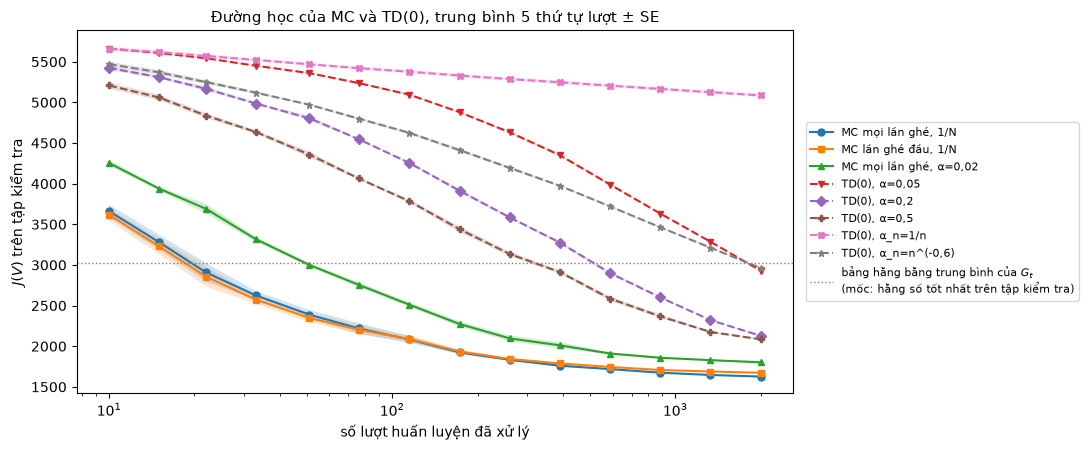

In [24]:
fig, ax = plt.subplots(figsize=(11, 4.6))
markers = ["o", "s", "^", "v", "D", "P", "X", "*"]
for (name, cv), mk in zip(curves.items(), markers):
    m, se = cv.mean(0), cv.std(0, ddof=1) / np.sqrt(len(cv))
    ls = "-" if name.startswith("MC") else "--"                          # nét liền: MC; nét đứt: TD
    ax.plot(CHECKPOINTS, m, ls=ls, marker=mk, ms=5, label=name)
    ax.fill_between(CHECKPOINTS, m - se, m + se, alpha=0.2)
ax.axhline(G_test.var(), color="gray", ls=":", lw=1, label="bảng hằng bằng trung bình của $G_t$\n(mốc: hằng số tốt nhất trên tập kiểm tra)")
ax.set_xscale("log")
ax.set_xlabel("số lượt huấn luyện đã xử lý")
ax.set_ylabel("$J(V)$ trên tập kiểm tra")
ax.set_title("Đường học của MC và TD(0), trung bình 5 thứ tự lượt ± SE", fontsize=11)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

Các bảng sau khi xử lý toàn bộ $2000$ lượt theo thứ tự gốc được so ở hai thước đo, kèm vài số đo dùng cho phần đọc kết quả: tổng số mẫu của hai quy tắc lần ghé, tỉ số có trọng số $\sum_sN(s)V_{1/n}(s)\big/\sum_sN(s)V_{\mathrm{MC}}(s)$ cho biết mức bảng TD(0) với $\alpha_n=1/n$ đã rời giá trị khởi tạo $0$, và số lần cập nhật tại các ô xuất phát.

In [25]:
V_first, N_first, _, _ = mc_prediction(train, N_CELLS, GAMMA, first_visit=True)
V_inv = td0_prediction(train, N_CELLS, GAMMA, alpha=None, power=1.0)[0]
V_final = {"MC mọi lần ghé, 1/N": V_mc, "MC lần ghé đầu, 1/N": V_first, "TD(0), α=0,5": V_td,
           "TD(0), α_n=1/n": V_inv, "TD(0), α_n=n^(-0,6)": td0_prediction(train, N_CELLS, GAMMA, alpha=None, power=0.6)[0]}
print(f"trung bình G_0 trên tập kiểm tra: {G0_test.mean():7.2f} ± {1.96 * G0_test.std(ddof=1) / np.sqrt(len(G0_test)):.2f}")
for name, V in V_final.items():
    print(f"{name:<22} trung bình V(S_0) = {V[S0_test].mean():7.2f}   J(V) = {J(V):7.1f}")
print(f"tổng số mẫu MC: mọi lần ghé {int(N_mc.sum())}, lần ghé đầu {int(N_first.sum())}")
w = N_td.astype(float)                                       # trọng số: số lần cập nhật TD của mỗi ô
print(f"tỉ số có trọng số sum N V_(1/n) / sum N V_MC = {(w * V_inv).sum() / (w * V_mc).sum():.3f}")
print(f"hệ số n^-(1-gamma) với n = 10^4: {1e4 ** -(1 - GAMMA):.3f}")
print(f"tại ô xuất phát của lượt kiểm tra: N trung bình {N_td[S0_test].mean():.0f}, "
      f"bước học 1/N trung bình {np.mean(1 / np.maximum(N_td[S0_test], 1)):.1e}")

trung bình G_0 trên tập kiểm tra:   56.04 ± 2.70
MC mọi lần ghé, 1/N    trung bình V(S_0) =   55.43   J(V) =  1626.8
MC lần ghé đầu, 1/N    trung bình V(S_0) =   54.36   J(V) =  1673.4
TD(0), α=0,5           trung bình V(S_0) =   52.33   J(V) =  2100.8
TD(0), α_n=1/n         trung bình V(S_0) =    1.04   J(V) =  5157.9
TD(0), α_n=n^(-0,6)    trung bình V(S_0) =    0.74   J(V) =  2950.7
tổng số mẫu MC: mọi lần ghé 504869, lần ghé đầu 83172
tỉ số có trọng số sum N V_(1/n) / sum N V_MC = 0.084
hệ số n^-(1-gamma) với n = 10^4: 0.912
tại ô xuất phát của lượt kiểm tra: N trung bình 580, bước học 1/N trung bình 2.2e-03


**Đọc kết quả.** Các nhận xét dưới chỉ áp dụng cho dữ liệu, cách chia ô và các bước học ở trên; số cụ thể nằm trong output.

- Đường của MC với $1/N(s)$ giảm nhanh ngay từ vài chục lượt đầu. Mục tiêu $G_t$ không đọc bảng hiện có; trên ô gộp, nó không chệch đối với $\mu$, còn đối với $v_\pi$ thì không chệch khi trạng thái có tính Markov (bài giảng gốc, tr. 26); bước học $1$ ở mẫu đầu tiên loại hoàn toàn giá trị khởi tạo $0$, phù hợp với nhận xét MC không quá nhạy với giá trị khởi tạo (tr. 28).
- Các đường TD(0) bắt đầu gần $J(\mathbf 0)$ in ở trên: bảng khởi tạo bằng $0$, và ô chưa nhận thông tin từ phần thưởng về sau giữ giá trị gần $0$. $J(\mathbf 0)$ bằng phương sai cộng bình phương trung bình của $G_t$, nên nằm trên đường của bảng hằng. Mục tiêu TD đọc bảng hiện có, nên có độ chệch $\gamma\,\mathbb E_\pi[V_t(S_{t+1})-v_\pi(S_{t+1})\mid S_t=s]$ (ghi chú Bài 05, mục Độ chệch của mục tiêu TD), lớn khi bảng còn gần $0$; bài giảng gốc (tr. 28) ghi TD nhạy với giá trị khởi tạo hơn MC. Mục tiêu MC không chệch nhưng phương sai cao hơn (ghi chú Bài 05, mục Phương sai của mục tiêu); trên dữ liệu này, độ chệch do khởi tạo của TD có thể là phần chiếm ưu thế trong $J$ ở đầu đường học. Bước học hằng lớn hơn cho đường thấp hơn trong phạm vi $2000$ lượt; theo mục 7.1, mỗi tự chuyển chỉ thu hẹp khoảng cách tới điểm cố định theo hệ số $1-\alpha(1-\gamma)$, nên $\alpha$ lớn truyền thông tin nhanh hơn.
- Với $\alpha_n=1/n$, trên một chuỗi tự chuyển tại ô $s$ với phần thưởng $r$, $V_n=V_{n-1}+\frac1n[r-(1-\gamma)V_{n-1}]$, nên khoảng cách tới $r/(1-\gamma)$ được nhân với $\prod_{k=1}^{n}\big(1-\frac{1-\gamma}k\big)\approx n^{-(1-\gamma)}$; với $n=10^4$, hệ số này còn khoảng $0{,}91$ (in ở output). Các ô được ghé nhiều có bước học rất nhỏ trong khi giá trị còn gần $0$; tỉ số có trọng số in ở output cho thấy toàn bảng mới đi được một phần nhỏ quãng đường tới bảng MC. Lịch $1/n$ thỏa điều kiện bước học của Bài 05, nhưng đó là bảo đảm khi số cập nhật tiến tới vô hạn, không cho biết gì về $2000$ lượt; bảo đảm đó còn giả thiết trạng thái Markov, điều ô gộp không thỏa. Lịch $n^{-0{,}6}$ cũng thỏa điều kiện và giảm bước học chậm hơn; trong output, đường của nó thấp hơn rõ so với $1/n$ nhưng cao hơn đường của các bước học hằng $0{,}2$ và $0{,}5$.
- MC lần ghé đầu và MC mọi lần ghé cho hai giá trị $J$ khác nhau khi đã xử lý hết dữ liệu. Có hai nguyên nhân: trên ô gộp, hai quy tắc ước lượng hai đại lượng khác nhau (mục 6.1), và lần ghé đầu dùng ít mẫu hơn nhiều (output in tổng số mẫu). $J$ đo theo mọi thời điểm nên ưu tiên đích của mọi lần ghé.
- Trung bình $V(S_0)$ của từng phương pháp được đặt cạnh khoảng tin cậy $95\%$ của $\mathbb E_\pi[G_0]$; đây là kiểm tra thô như đã nêu ở đầu phần. Với $\alpha_n=1/n$ và $\alpha_n=n^{-0{,}6}$, trung bình $V(S_0)$ còn gần giá trị khởi tạo $0$; output in số lần cập nhật và bước học $1/N$ trung bình tại các ô xuất phát.

Bài giảng gốc (tr. 28) ghi TD "thường hiệu quả mẫu tốt hơn MC", còn ghi chú Bài 05 nêu rằng không có thứ tự phương sai hay hiệu quả mẫu phổ quát giữa hai phương pháp. Trên dữ liệu này, output cho thứ tự ngược lại; đây là một trường hợp cụ thể với ô gộp không Markov, khởi tạo bằng $0$, chuyển dài $0{,}02$ giây và nhiều tự chuyển. Phần 12 gợi ý các thay đổi để kiểm tra kết quả khi các điều kiện này thay đổi, trong đó có khởi tạo $V$ khác $0$.

**Câu hỏi:** Giải thích vì sao đường của MC mọi lần ghé với $\alpha=0{,}02$ không tiến tới đường của MC với $1/N(s)$ khi số lượt tăng, dù hai cấu hình dùng cùng các mẫu.

<details><summary>Lời giải</summary>

Với bước học hằng, $V_n(s)=(1-\alpha)^nV_0(s)+\sum_{i=1}^n\alpha(1-\alpha)^{n-i}g_i(s)$: mẫu gần nhất có trọng số $\alpha$, các mẫu cũ có trọng số giảm theo $(1-\alpha)$. Ước lượng tiếp tục dao động theo các mẫu mới; với $\sum_n\alpha^2=\infty$, điều kiện bảo đảm hội tụ của Bài 05 không áp dụng. Trung bình mẫu $1/N(s)$ cho mọi mẫu cùng trọng số, nên nhiễu của từng lợi tức bị triệt tiêu dần. Ở các ô ít được ghé, giá trị khởi tạo $0$ còn ảnh hưởng qua hệ số $(1-\alpha)^n$ khi $n$ nhỏ.

</details>

## 9. Dự đoán trên dữ liệu cố định

**Vấn đề.** Đường học ở phần 8 xử lý mỗi lượt một lần. Khi chỉ có một tập dữ liệu cố định, có thể quét lại dữ liệu nhiều lần đến khi bảng ổn định. Ghi chú Bài 05 cho thấy hai phương pháp khi đó hội tụ về hai nghiệm khác nhau: MC theo lô khớp lợi tức quan sát, TD theo lô khớp quan hệ Markov thực nghiệm.

### 9.1. Kiểm tra lại ví dụ $A$, $B$ của ghi chú

Tập dữ liệu gồm tám lượt với $\gamma=1$: một lượt $A\xrightarrow{0}B\xrightarrow{0}$ kết thúc, sáu lượt $B\xrightarrow{1}$ kết thúc, một lượt $B\xrightarrow{0}$ kết thúc. Quy trình cập nhật theo lô của ghi chú, với $k$ đếm lượt quét:

1. giữ $V_k$ cố định, đặt $\Delta_k(s)=0$;
2. quét mọi mẫu: MC dùng lợi tức đã tính, TD dùng $R_{t+1}+\gamma V_k(S_{t+1})$;
3. với mỗi mẫu tại $s$ có mục tiêu $y$: $\Delta_k(s)\leftarrow\Delta_k(s)+\alpha\,[y-V_k(s)]$;
4. ghi đồng thời $V_{k+1}(s)=V_k(s)+\Delta_k(s)$;
5. lặp tới khi $\max_s\lvert V_{k+1}(s)-V_k(s)\rvert<\varepsilon$ hoặc đủ $K$ lượt quét.

Với $\alpha=1/8$, ghi chú tính được $V_1=(0;\ 3/4)$ cho cả hai phương pháp, quét thứ hai của TD cho $V_2(A)=3/32$, và hai nghiệm giới hạn $V_{\mathrm{MC}}=(0;\ 3/4)$, $V_{\mathrm{TD}}=(3/4;\ 3/4)$. Hàm `batch_sweep` dưới thực hiện bước 1–4 và kiểm tra lại các số này (ghi chú Bài 05, mục Dự đoán trên dữ liệu cố định; Sutton–Barto, §6.3, tr. 126–128, Ví dụ 6.4).

In [26]:
def batch_sweep(samples, V, alpha, gamma):
    # samples: danh sách (s, y_mc, r, s_next); s_next = None nếu chuyển vào kết thúc. Trả V_(k+1) của MC và TD
    d_mc = {s: 0.0 for s in V}                                    # bước 1: Delta_k(s) = 0
    d_td = {s: 0.0 for s in V}
    for s, g, r, s_next in samples:                               # bước 2–3: mục tiêu đọc từ V_k cố định
        d_mc[s] += alpha * (g - V[s])
        y_td = r + gamma * (0.0 if s_next is None else V[s_next])
        d_td[s] += alpha * (y_td - V[s])
    return ({s: V[s] + d_mc[s] for s in V}, {s: V[s] + d_td[s] for s in V})   # bước 4: ghi đồng thời


# Tám lượt của ghi chú, viết thành các mẫu (s, G_t, R_(t+1), S_(t+1))
samples_AB = [("A", 0.0, 0.0, "B"), ("B", 0.0, 0.0, None)] + [("B", 1.0, 1.0, None)] * 6 + [("B", 0.0, 0.0, None)]
V0 = {"A": 0.0, "B": 0.0}
V1_mc, V1_td = batch_sweep(samples_AB, V0, 1 / 8, 1.0)
V2_mc, _ = batch_sweep(samples_AB, V1_mc, 1 / 8, 1.0)
_, V2_td = batch_sweep(samples_AB, V1_td, 1 / 8, 1.0)
print("quét 1 — MC:", V1_mc, " TD:", V1_td)
print("quét 2 — MC:", V2_mc, " TD:", V2_td)
assert V1_mc == V1_td == {"A": 0.0, "B": 0.75}
assert V2_mc == {"A": 0.0, "B": 0.75} and np.isclose(V2_td["A"], 3 / 32) and np.isclose(V2_td["B"], 0.75)

Vm, Vt = dict(V0), dict(V0)
for k in range(1, 1001):                                          # bước 5: lặp tới khi thay đổi nhỏ
    Vm_new = batch_sweep(samples_AB, Vm, 1 / 8, 1.0)[0]
    Vt_new = batch_sweep(samples_AB, Vt, 1 / 8, 1.0)[1]
    change = max(abs(Vm_new[s] - Vm[s]) + abs(Vt_new[s] - Vt[s]) for s in V0)
    Vm, Vt = Vm_new, Vt_new
    if change < 1e-10:
        break
print(f"sau {k} lượt quét — MC: {Vm}  TD: {Vt}")
assert np.isclose(Vm["A"], 0) and np.isclose(Vm["B"], 0.75) and np.isclose(Vt["A"], 0.75) and np.isclose(Vt["B"], 0.75)

quét 1 — MC: {'A': 0.0, 'B': 0.75}  TD: {'A': 0.0, 'B': 0.75}
quét 2 — MC: {'A': 0.0, 'B': 0.75}  TD: {'A': 0.09375, 'B': 0.75}
sau 157 lượt quét — MC: {'A': 0.0, 'B': 0.75}  TD: {'A': 0.749999999326531, 'B': 0.75}


### 9.2. MC theo lô và TD theo lô trên Lunar Lander

**MC theo lô.** Nghiệm của MC theo lô cực tiểu tổng bình phương $\sum(G_t-V(S_t))^2$ trên tập huấn luyện, nên tại mỗi ô bằng trung bình các lợi tức quan sát tại ô đó. Đây chính là bảng `V_mc` của mục 6.2 (đã kiểm tra bằng trung bình cộng theo ô).

**TD theo lô.** Ở bước 3 của quy trình theo lô, bước học hằng $\alpha$ cộng $N(s)$ gia số tại ô $s$; ô được ghé nhiều nhất có hàng chục nghìn mẫu (phần 5), nên cần $\alpha$ rất nhỏ để quy trình ổn định, và hội tụ khi đó rất chậm. Notebook dùng bước học riêng cho mỗi ô $\alpha/N(s)$ với $\alpha=1$:

$$V_{k+1}(s)=\frac1{N(s)}\sum_{\text{mẫu tại }s}\big[R_{t+1}+\gamma V_k(S_{t+1})\big]=\hat r(s)+\gamma\sum_{s'}\hat P(s'\mid s)\,V_k(s'),$$

trong đó $\hat r(s)$ là phần thưởng trung bình và $\hat P(s'\mid s)$ là tần suất chuyển từ $s$ sang $s'$ trong dữ liệu (chuyển vào trạng thái kết thúc không đóng góp vào tổng). Vì chính sách cố định, hành động không xuất hiện trong ký hiệu: $\hat P$ và $\hat r$ là ước lượng thực nghiệm của $P_\pi$ và $r_\pi$ trong dạng ma trận của Bài 04. Điều kiện dừng "tổng sai số TD tại mỗi ô bằng $0$" tương đương "trung bình sai số TD tại mỗi ô bằng $0$", nên hai cách chọn bước học có cùng nghiệm giới hạn. Vế phải là toán tử $T_\pi$ của Bài 04 áp dụng cho quá trình phần thưởng Markov (MRP) thực nghiệm $(\hat P,\hat r)$; với $\gamma<1$, toán tử này co theo chuẩn vô cùng, nên dãy hội tụ và có thể dùng chặn sai số $\Delta/(1-\gamma)$ của Bài 04 với ngưỡng $\eta=(1-\gamma)\varepsilon$. Phép lặp chỉ đọc các mẫu, không dựng $\hat P$ tường minh; đoạn mã sau đó dựng $\hat P$ trên các ô đã ghé và giải hệ $(I-\gamma\hat P)V=\hat r$ để kiểm tra.

MC theo lô chỉ dùng các lượt kết thúc thật, còn TD theo lô dùng được cả các chuyển của lượt bị cắt ngắn. Để so hai nghiệm trên cùng dữ liệu, hàm `batch_td` được chạy hai lần: trên toàn bộ tập huấn luyện và trên riêng các lượt kết thúc thật.

| Ký hiệu | Biến trong mã | Kích thước |
| --- | --- | --- |
| các mẫu $(S_t,R_{t+1},S_{t+1})$ | `S`, `Rw`, `S_next`, cờ kết thúc `end` | số chuyển $\approx5{,}5\cdot10^5$ |
| $N(s)$ | `Ns` | $9216$ |
| $V_k$, $V_{k+1}$ | `V`, `W` | $9216$ |

In [27]:
def transitions(episodes):
    # Ghép mọi chuyển: S_t, S_(t+1), R_(t+1) và cờ "S_(t+1) là trạng thái kết thúc thật"
    S = np.concatenate([e["cells"][:-1] for e in episodes])
    S_next = np.concatenate([e["cells"][1:] for e in episodes])
    Rw = np.concatenate([e["rewards"] for e in episodes])
    end = np.concatenate([np.r_[np.zeros(len(e["actions"]) - 1, bool), e["terminated"]] for e in episodes])
    return S, S_next, Rw, end


def batch_td(episodes, n_cells, gamma, eta, max_sweeps=20_000):
    # TD theo lô với bước học 1/N(s): V_(k+1)(s) = trung bình các mục tiêu R + gamma V_k(S') tại s
    S, S_next, Rw, end = transitions(episodes)
    Ns = np.bincount(S, minlength=n_cells)                                # N(s), cỡ (n_cells,)
    V = np.zeros(n_cells)
    for k in range(max_sweeps):
        Y = Rw + gamma * np.where(end, 0.0, V[S_next])                    # mục tiêu TD đọc từ V_k cố định
        W = np.where(Ns > 0, np.bincount(S, weights=Y, minlength=n_cells) / np.maximum(Ns, 1), 0.0)
        delta = np.abs(W - V).max()                                       # phần dư của bảng V_k
        if delta <= eta:
            break
        V = W
    return V, k, delta


EPS_VAL = 0.01
ETA = (1 - GAMMA) * EPS_VAL                                               # ngưỡng phần dư, như Bài 04
S, S_next, Rw, end = transitions(train)
Ns = np.bincount(S, minlength=N_CELLS)
print("số mẫu lớn nhất tại một ô:", Ns.max())
t0 = time.time()
V_btd, k, delta = batch_td(train, N_CELLS, GAMMA, ETA)
print(f"TD theo lô, toàn bộ tập huấn luyện: dừng sau k = {k} lượt quét, phần dư {delta:.1e} <= eta = {ETA:.0e} "
      f"({time.time() - t0:.1f} giây); chặn sai số so với nghiệm: {delta / (1 - GAMMA):.1e}")
train_end = [e for e in train if e["terminated"]]
V_btd_end, k2, delta2 = batch_td(train_end, N_CELLS, GAMMA, ETA)
print(f"TD theo lô, chỉ lượt kết thúc thật ({len(train_end)} lượt): dừng sau k = {k2} lượt quét")

# Kiểm tra bằng giải hệ (I - gamma P_hat) V = r_hat trên các ô đã ghé (toàn bộ tập huấn luyện)
seen = np.flatnonzero(Ns > 0)
pos = -np.ones(N_CELLS, int); pos[seen] = np.arange(len(seen))           # chỉ số ô -> chỉ số trong hệ
mask = ~end & (Ns[S_next] > 0)                                           # chuyển sang ô đã ghé
P_hat = np.zeros((len(seen), len(seen)))
np.add.at(P_hat, (pos[S[mask]], pos[S_next[mask]]), 1.0)
P_hat /= Ns[seen][:, None]                                               # P_hat(s' | s), cỡ (n_ghé, n_ghé)
r_hat = np.bincount(S, weights=Rw, minlength=N_CELLS)[seen] / Ns[seen]   # r_hat(s)
V_solve = np.linalg.solve(np.eye(len(seen)) - GAMMA * P_hat, r_hat)
n_lost = int((~end & (Ns[S_next] == 0)).sum())
print(f"hệ tuyến tính {len(seen)} ẩn; {n_lost} chuyển đi tới ô không có mẫu nào (giá trị 0)")
print(f"sai lệch lớn nhất giữa phép lặp và nghiệm của hệ: {np.abs(V_btd[seen] - V_solve).max():.1e}")
assert np.abs(V_btd[seen] - V_solve).max() <= delta / (1 - GAMMA) + 1e-9

số mẫu lớn nhất tại một ô: 24905


TD theo lô, toàn bộ tập huấn luyện: dừng sau k = 598 lượt quét, phần dư 9.9e-05 <= eta = 1e-04 (2.1 giây); chặn sai số so với nghiệm: 9.9e-03


TD theo lô, chỉ lượt kết thúc thật (1958 lượt): dừng sau k = 578 lượt quét
hệ tuyến tính 1935 ẩn; 0 chuyển đi tới ô không có mẫu nào (giá trị 0)
sai lệch lớn nhất giữa phép lặp và nghiệm của hệ: 6.6e-03


Bảng dưới so các nghiệm theo lô với hai bảng TD(0) trực tuyến của phần 8 trên hai thước đo của phần 8. Hai dòng đầu dùng đúng cùng dữ liệu (các lượt kết thúc thật); dòng thứ ba thêm các chuyển của lượt bị cắt ngắn.

In [28]:
rows = {"MC theo lô (lượt kết thúc thật)": V_mc, "TD theo lô (lượt kết thúc thật)": V_btd_end,
        "TD theo lô (toàn bộ tập huấn luyện)": V_btd,
        "TD(0) trực tuyến, α=0,5": V_td, "TD(0) trực tuyến, α_n=1/n": V_final["TD(0), α_n=1/n"]}
print(f"trung bình G_0 trên tập kiểm tra: {G0_test.mean():7.2f} ± {1.96 * G0_test.std(ddof=1) / np.sqrt(len(G0_test)):.2f}")
for name, V in rows.items():
    print(f"{name:<38} J(V) = {J(V):7.1f}   trung bình V(S_0) = {V[S0_test].mean():7.2f}")
seen_end = np.flatnonzero(np.bincount(transitions(train_end)[0], minlength=N_CELLS) > 0)
diff = np.abs(V_mc - V_btd_end)[seen_end]
print(f"|V_MC - V_TD| (cùng các lượt kết thúc thật) trên các ô đã ghé: trung vị {np.median(diff):.1f}, "
      f"phân vị 90% {np.percentile(diff, 90):.1f}")
print(f"tỉ số có trọng số sum N V_(1/n) / sum N V_TD theo lô = {(Ns * V_final['TD(0), α_n=1/n']).sum() / (Ns * V_btd).sum():.3f}")

trung bình G_0 trên tập kiểm tra:   56.04 ± 2.70
MC theo lô (lượt kết thúc thật)        J(V) =  1626.8   trung bình V(S_0) =   55.43
TD theo lô (lượt kết thúc thật)        J(V) =  1803.4   trung bình V(S_0) =   58.13
TD theo lô (toàn bộ tập huấn luyện)    J(V) =  1835.8   trung bình V(S_0) =   57.43
TD(0) trực tuyến, α=0,5                J(V) =  2100.8   trung bình V(S_0) =   52.33
TD(0) trực tuyến, α_n=1/n              J(V) =  5157.9   trung bình V(S_0) =    1.04


|V_MC - V_TD| (cùng các lượt kết thúc thật) trên các ô đã ghé: trung vị 15.2, phân vị 90% 58.1
tỉ số có trọng số sum N V_(1/n) / sum N V_TD theo lô = 0.088


**Giải thích.** Hai nghiệm theo lô ở hai dòng đầu dùng cùng dữ liệu và đều đã hội tụ, nên khác biệt giữa chúng không đến từ số lượt quét hay bước học. MC theo lô khớp trực tiếp lợi tức quan sát tại mỗi ô. TD theo lô khớp MRP thực nghiệm trên các ô: nó giả định rằng từ một ô, phần còn lại của lượt chỉ phụ thuộc vào ô đó. Như ví dụ $A$, $B$, khi dữ liệu không thỏa giả định Markov trên ô, hai nghiệm khác nhau. Ở đây, quan sát bên trong cùng một ô có $\Phi$ khác nhau (phần 2), và hướng mà lượt đi vào ô có thể mang thông tin về vị trí bên trong ô; MRP thực nghiệm trộn các lượt này lại. Nhiệm vụ 10 ở phần 12 kiểm tra trực tiếp giả định Markov trên ô. Trên tập huấn luyện, nghiệm MC theo lô có tổng bình phương sai số nhỏ nhất theo định nghĩa. Trên tập kiểm tra, phân rã ở phần 8 cho thấy $J$ đo khoảng cách tới $\mu$; output so $J$ của hai nghiệm, và đặt trung bình $V(S_0)$ của chúng cạnh khoảng tin cậy của $\mathbb E_\pi[G_0]$. Dòng thứ ba cho biết việc thêm các chuyển của lượt bị cắt ngắn làm nghiệm TD theo lô thay đổi bao nhiêu trên hai thước đo.

Bảng cũng cho thấy TD(0) trực tuyến sau một lần đi qua $2000$ lượt còn cách nghiệm TD theo lô trên cùng dữ liệu; với $\alpha_n=1/n$, tỉ số có trọng số in ở dòng cuối cho biết bảng mới đi được bao nhiêu phần quãng đường tới nghiệm đó. Một lần đi qua dữ liệu chưa đủ cho TD hội tụ khi phần lớn chuyển là tự chuyển. Các kết quả về hội tụ của TD(0) dạng bảng trong Bài 05 giả thiết trạng thái Markov; khi trạng thái là ô gộp, bảng chính là một trường hợp đặc biệt của xấp xỉ hàm tuyến tính (đặc trưng là vector one-hot của ô), và phân tích hội tụ cho trường hợp đó thuộc Bài 07 (Tsitsiklis và Van Roy, 1997).

**Câu hỏi:** Trong ví dụ $A$, $B$, nghiệm TD đặt $V(A)=3/4$ dù lợi tức duy nhất quan sát được tại $A$ bằng $0$. Nêu điều kiện trên môi trường thật để nghiệm TD là ước lượng tốt hơn của $v_\pi(A)$, và liên hệ với Lunar Lander.

<details><summary>Lời giải</summary>

Nghiệm TD dùng mọi lượt đi qua $B$ để ước lượng phần sau $B$, kể cả các lượt bắt đầu ở $B$. Điều này đúng khi quá trình là Markov trên các trạng thái đang dùng: phần sau $B$ có cùng phân phối dù tác tử đến $B$ từ $A$ hay bắt đầu ở $B$. Khi đó nghiệm TD dựa trên tám mẫu cho phần sau $B$ thay vì một lợi tức tại $A$. Nếu việc đến $B$ từ $A$ làm thay đổi phần còn lại, nghiệm TD bị lệch. Trên Lunar Lander, các ô gộp nhiều quan sát có $\Phi$ khác nhau, và lượt đến một ô từ một hướng cụ thể có thể nằm ở một phần cụ thể của ô; giả định Markov trên ô không được bảo đảm, nên nghiệm TD theo lô có thể lệch khỏi trung bình lợi tức theo ô như output cho thấy.

</details>

## 10. Trực quan hóa dự đoán

### 10.1. Dự đoán dọc một lượt kiểm tra

Đồ thị dưới đặt lợi tức thực tế $G_t$ của một lượt kiểm tra cạnh $V(S_t)$ của nghiệm MC theo lô và nghiệm TD theo lô. Lượt được chọn là lượt kết thúc bằng nằm yên đầu tiên trong tập kiểm tra. $V(S_t)$ là hằng số trong suốt thời gian tàu ở lại cùng một ô, nên đường dự đoán có dạng bậc thang, còn $G_t$ thay đổi ở mọi bước. $V$ ước lượng lợi tức trung bình trên mọi lượt đi qua ô, kể cả các lượt rơi; một lượt kết thúc bằng nằm yên vì thế có thể có $G_t$ nằm trên các dự đoán. Output kiểm tra hai cách giải thích cho khoảng chênh ở $30$ bước cuối của lượt. Thứ nhất, ô gộp có thể trộn lượt nhận $+100$ với lượt nhận $-100$; output in tỉ lệ mẫu huấn luyện tại các ô đó thuộc lượt rơi. Thứ hai, ô có thể trộn các thời điểm cách xa và gần kết thúc: tàu đứng trên bãi một số bước khác nhau trước khi bộ mô phỏng chuyển thân tàu sang trạng thái nghỉ, và phần thưởng $+100$ đóng góp $\gamma^{T-1-t}\cdot100$ vào $G_t$, giảm theo số bước còn lại. Các số đo chỉ dùng lượt kết thúc thật, cùng dữ liệu với $V_{\mathrm{MC}}$: output in trung bình và trung vị của $T-t$, và trung bình của $\gamma^{T-1-t}$ cho các mẫu huấn luyện tại các ô đó so với $30$ bước cuối của lượt đang xét. Nếu tỉ lệ lượt rơi gần $0$ và $100$ lần chênh lệch của trung bình $\gamma^{T-1-t}$ chiếm phần lớn khoảng chênh giữa $G_t$ và $V_{\mathrm{MC}}$ in ở dòng đầu, khoảng chênh phù hợp với cách giải thích thứ hai; phần còn lại đến từ các phần thưởng định hình và chi phí nhiên liệu.

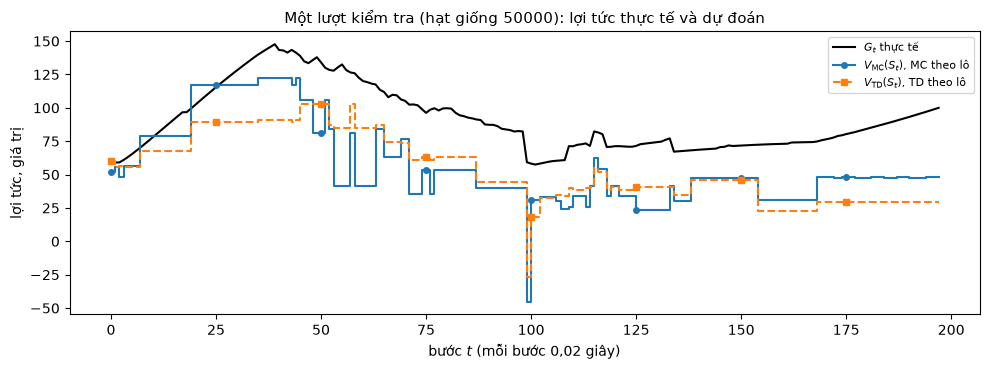

lượt dài 198 bước, đi qua 31 ô khác nhau; sai số bình phương trung bình dọc lượt: MC 1571.1, TD 1590.8
30 bước cuối: G_t trung bình 86.8, V_MC trung bình 48.2, chênh 38.6
mẫu huấn luyện tại các ô này: tỉ lệ thuộc lượt rơi 0.00; T - t trung bình 139, trung vị 46
trung bình gamma^(T-1-t): 0.546 cho các mẫu huấn luyện tại các ô này, 0.868 cho 30 bước cuối lượt đang xét -> 100 x chênh lệch = 32.1


In [29]:
ep_v = next(e for e in test if e["terminated"] and outcome(e) == "nằm yên (+100)")
G_v = compute_returns(ep_v["rewards"], GAMMA)
c_v = ep_v["cells"][:-1]
fig, ax = plt.subplots(figsize=(10, 3.8))
t_axis = np.arange(len(G_v))
ax.plot(t_axis, G_v, color="k", lw=1.5, label="$G_t$ thực tế")
ax.step(t_axis, V_mc[c_v], where="post", ls="-", marker="o", markevery=25, ms=4, label=r"$V_{\mathrm{MC}}(S_t)$, MC theo lô")
ax.step(t_axis, V_btd[c_v], where="post", ls="--", marker="s", markevery=25, ms=4, label=r"$V_{\mathrm{TD}}(S_t)$, TD theo lô")
ax.set_xlabel("bước $t$ (mỗi bước 0,02 giây)"); ax.set_ylabel("lợi tức, giá trị")
ax.set_title(f"Một lượt kiểm tra (hạt giống {ep_v['seed']}): lợi tức thực tế và dự đoán", fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
n_cells_v = len(np.unique(c_v))
print(f"lượt dài {len(G_v)} bước, đi qua {n_cells_v} ô khác nhau; "
      f"sai số bình phương trung bình dọc lượt: MC {np.mean((G_v - V_mc[c_v]) ** 2):.1f}, TD {np.mean((G_v - V_btd[c_v]) ** 2):.1f}")
# Mẫu huấn luyện của V_MC (chỉ lượt kết thúc thật) tại các ô của 30 bước cuối lượt này
S_e = np.concatenate([e["cells"][:-1] for e in train_end])
crash = np.concatenate([np.full(len(e["actions"]), outcome(e) == "rơi hoặc ra ngoài (-100)") for e in train_end])
to_end = np.concatenate([np.arange(len(e["actions"]), 0, -1) for e in train_end])   # T - t của từng mẫu
disc = GAMMA ** (to_end - 1)                                        # gamma^(T-1-t): hệ số của phần thưởng cuối trong G_t
in_tail = np.isin(S_e, np.unique(c_v[-30:]))
gap = G_v[-30:].mean() - V_mc[c_v[-30:]].mean()
print(f"30 bước cuối: G_t trung bình {G_v[-30:].mean():.1f}, V_MC trung bình {V_mc[c_v[-30:]].mean():.1f}, chênh {gap:.1f}")
print(f"mẫu huấn luyện tại các ô này: tỉ lệ thuộc lượt rơi {crash[in_tail].mean():.2f}; "
      f"T - t trung bình {to_end[in_tail].mean():.0f}, trung vị {np.median(to_end[in_tail]):.0f}")
d_ep = (GAMMA ** np.arange(29, -1, -1)).mean()                      # cùng đại lượng cho 30 bước cuối lượt đang xét
print(f"trung bình gamma^(T-1-t): {disc[in_tail].mean():.3f} cho các mẫu huấn luyện tại các ô này, "
      f"{d_ep:.3f} cho 30 bước cuối lượt đang xét -> 100 x chênh lệch = {100 * (d_ep - disc[in_tail].mean()):.1f}")

### 10.2. Bản đồ giá trị theo vị trí

Bảng $V$ có $9216$ phần tử, không vẽ trực tiếp được. Hình dưới chỉ xét các ô khi tàu chưa chạm đất ($l_1+l_2=0$), và gộp theo hai chỉ số vị trí $(b_x,b_y)$: mỗi ô của lưới $3\times4$ ghi trung bình của $V$ trên các ô đã ghé có cùng $(b_x,b_y)$, có trọng số là số lần ghé. Mỗi ô ghi số cụ thể, nên hình đọc được cả khi không phân biệt màu.

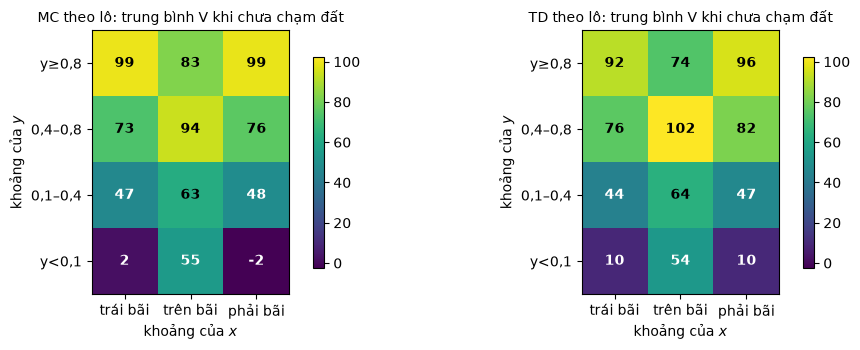

In [30]:
def position_map(V, visits, cuts):
    # Trung bình có trọng số của V theo (b_x, b_y), chỉ xét các ô có số chân chạm đất bằng 0
    shape = grid_shape(cuts)
    Vg = V.reshape(shape)[..., 0]                    # (3, 4, 4, 4, 4, 4): bỏ trục số chân
    wg = visits.reshape(shape)[..., 0].astype(float)
    axes_rest = tuple(range(2, Vg.ndim))
    w = wg.sum(axis=axes_rest)                       # tổng số lần ghé theo (b_x, b_y), cỡ (3, 4)
    return np.where(w > 0, (Vg * wg).sum(axis=axes_rest) / np.maximum(w, 1), np.nan), w


maps = {name: position_map(V, Ns, CUTS)[0] for name, V in [("MC theo lô", V_mc), ("TD theo lô", V_btd)]}
vmin = min(np.nanmin(M) for M in maps.values()); vmax = max(np.nanmax(M) for M in maps.values())   # cùng thang màu
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
xlab = ["trái bãi", "trên bãi", "phải bãi"]
ylab = ["y<0,1", "0,1–0,4", "0,4–0,8", "y≥0,8"]
for ax, (name, M) in zip(axes, maps.items()):
    im = ax.imshow(M.T, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            txt = "—" if np.isnan(M[i, j]) else f"{M[i, j]:.0f}"
            light = (M[i, j] - vmin) / (vmax - vmin) > 0.6               # chữ đen trên nền sáng, chữ trắng trên nền tối
            ax.text(i, j, txt, ha="center", va="center", color="k" if light else "w", fontsize=10, fontweight="bold")
    ax.set_xticks(range(3)); ax.set_xticklabels(xlab)
    ax.set_yticks(range(4)); ax.set_yticklabels(ylab)
    ax.set_xlabel("khoảng của $x$"); ax.set_ylabel("khoảng của $y$")
    ax.set_title(f"{name}: trung bình V khi chưa chạm đất", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

Trong output, ở hai cột bên ngoài bãi, giá trị trung bình tăng theo độ cao. Điều này phù hợp với số hạng $-\Phi(S_t)$ trong lợi tức ở phần 2: tàu càng cao và càng xa bãi đáp thì phần thưởng định hình còn nhận được càng lớn; các số hạng khác của lợi tức cũng thay đổi theo vị trí, nên bản đồ không tách được riêng ảnh hưởng của $\Phi$. Giá trị lớn ở đây chỉ phần thưởng còn lại lớn; câu hỏi ở phần 2 xét cách so sánh hai vị trí theo triển vọng hạ cánh. Ở hàng sát mặt đất, ô trên bãi có giá trị lớn hơn rõ so với hai ô bên ngoài bãi. Hai bản đồ dùng chung thang màu và cùng dữ liệu; chênh lệch giữa chúng tại cùng một ô lưới là chênh lệch giữa hai nghiệm theo lô ở mục 9.2 sau khi lấy trung bình.

### 10.3. Hoạt hình kèm dự đoán

Trình phát của mục 3.1 được dùng lại cho lượt kiểm tra ở mục 10.1, với một dòng số liệu dưới tiêu đề: lợi tức thực tế $G_t$ và hai dự đoán $V_{\mathrm{MC}}(S_t)$, $V_{\mathrm{TD}}(S_t)$ tại bước đang phát.

In [31]:
ep_show = run_episode(env, pi_policy, ep_v["seed"], keep_terrain=True)       # chạy lại để lấy địa hình
assert len(ep_show["actions"]) == len(ep_v["actions"])                        # trùng lượt trong tập kiểm tra
name_show = "π, lượt kiểm tra"
info = {"G_t": {name_show: G_v}, "V_MC": {name_show: V_mc[c_v]}, "V_TD": {name_show: V_btd[c_v]}}
display(HTML(lander_player({name_show: ep_show}, info=info)))

Trình phát: 1 lượt, dài nhất 198 bước; HTML nhúng 18 kB


## 11. Tổng kết

- Lunar Lander rời rạc, không gió, được biểu diễn bằng $9216$ ô; chính sách $\pi$ là heuristic của Gymnasium với $\varepsilon=0{,}1$. Đánh giá qua nhiều lượt cho tổng thưởng và $G_0$ kèm SE; hoạt hình và đồ thị cho thấy từng lượt.
- Monte Carlo tính lợi tức bằng cách duyệt lùi, chọn mẫu theo lần ghé đầu tiên hoặc mọi lần ghé, và cập nhật bằng trung bình mẫu hoặc bước học hằng; trung bình cập nhật dần trùng trung bình cộng theo ô. MC không dùng được lượt bị cắt ngắn.
- TD(0) cập nhật sau từng chuyển bằng $Y_t=R_{t+1}+\gamma V_t(S_{t+1})$, dùng được cả chuyển của lượt bị cắt ngắn; ở dữ liệu này, phần lớn chuyển là tự chuyển và TD truyền thông tin chậm hơn MC.
- Trên dữ liệu cố định, MC theo lô bằng trung bình lợi tức theo ô; TD theo lô là nghiệm của MRP thực nghiệm, tính bằng toán tử $T_\pi$ của Bài 04 và kiểm tra bằng giải hệ tuyến tính. Hai nghiệm khác nhau vì ô gộp không bảo đảm tính Markov.
- Các kết luận so sánh trong notebook gắn với cách chia ô, bước học, $\gamma$ và lượng dữ liệu đã dùng.

## 12. Gợi mở tìm hiểu và cải tiến

Mỗi nhiệm vụ nêu việc cần làm và đại lượng cần đo. Hàm `prediction_pipeline` dưới gói các bước của phần 4–9 cho một cách chia ô mới, dùng lại dữ liệu đã thu (quan sát gốc được giữ trong mỗi lượt), nên không cần chạy lại môi trường; hàm trả số ô, tỉ lệ tự chuyển, $J$ và các bảng $V$. Để vẽ đường học cho cách chia mới, gọi `mc_prediction` hoặc `td0_prediction` với tham số `checkpoints` và `eval_fn` như mục 8.1.

1. **Cách chia ô.** Thay `CUTS` bằng cách chia thô hơn (ví dụ bỏ điểm cắt $0$ của $v_x$, $\varphi$, $\omega$) và mịn hơn (thêm điểm cắt cho $x$, $y$). Với mỗi cách, đo số ô được ghé, tỉ lệ tự chuyển, $J$ của MC theo lô và TD theo lô, và đường học. Một cách chia theo phân vị của dữ liệu (`np.quantile`) cho mỗi khoảng cùng số quan sát; so sánh với cách chia theo ý nghĩa vật lý ở phần 4.
2. **Lịch bước học của TD(0).** Thử $\alpha_n=n^{-p}$ với $p\in\{0{,}51;\ 0{,}6;\ 0{,}8;\ 1\}$ và $\alpha_n=c/(c+n)$ với vài giá trị $c$. Kiểm tra lịch nào thỏa $\sum_n\alpha_n=\infty$, $\sum_n\alpha_n^2<\infty$, và so sánh đường học với bước học hằng.
3. **Nhiều lượt quét trực tuyến.** Cho TD(0) và MC đi qua tập huấn luyện nhiều lần (mỗi lần một thứ tự lượt khác) và vẽ $J$ theo số lần đi qua; đối chiếu với hai nghiệm theo lô ở mục 9.2.
4. **Gộp các tự chuyển.** Thay mỗi chuỗi $m$ bước liên tiếp trong cùng một ô bằng một chuyển duy nhất với phần thưởng $\sum_{i=0}^{m-1}\gamma^iR_{t+i+1}$ và hệ số $\gamma^m$ cho giá trị tiếp nối. Cài đặt cập nhật TD tương ứng và so sánh tốc độ học với TD(0) thường. Đây là một thử nghiệm; cần tự kiểm tra mục tiêu mới vẫn có kỳ vọng phù hợp với $v_\pi$ khi trạng thái là Markov.
5. **TD $n$ bước (xem trước).** Mục tiêu $G_{t:t+n}=R_{t+1}+\gamma R_{t+2}+\dots+\gamma^{n-1}R_{t+n}+\gamma^nV(S_{t+n})$ nối TD(0) ($n=1$) với MC ($n\ge T-t$); Sutton–Barto, ấn bản 2, §7.1, tr. 142–145. Khung hàm ở ô dưới; so sánh $n\in\{1,4,16,64\}$.
6. **Chính sách khác.** Đổi $\varepsilon$ thành $0$ hoặc $0{,}3$, hoặc dùng chính sách ngẫu nhiên. Đo độ phủ, phương sai của $G_t$ và đường học; giải thích bằng phân rã của $J$ ở phần 8.
7. **Có gió.** (a) Tạo môi trường với `enable_wind=True` (mặc định `wind_power=15.0`, `turbulence_power=1.5`). Lực gió là hàm của một chỉ số nội bộ, rút ngẫu nhiên khi `reset` và tăng sau mỗi bước khi tàu chưa chạm đất; chỉ số này không có trong quan sát, nên quan sát không có tính Markov ngay cả trước khi rời rạc hóa. Phân phối của các lượt vẫn giống nhau giữa các lượt, nên môi trường vẫn dừng theo nghĩa của Bài 05. Lặp lại phần 5–9 và so sánh chênh lệch giữa hai nghiệm theo lô với trường hợp không gió. (b) Môi trường không dừng thật cần thay đổi điều kiện trong lúc học, ví dụ tăng `wind_power` sau mỗi $500$ lượt huấn luyện. Bài giảng gốc (tr. 21) nêu bước học hằng cho trường hợp này; so sánh MC và TD với bước học hằng và với $1/N(s)$ khi `wind_power` thay đổi.
8. **Xấp xỉ hàm (xem trước Bài 07).** Thay bảng bằng $\hat v(s,\mathbf w)=\mathbf w^\top\mathbf x(s)$ với các đặc trưng là các biến quan sát, $\Phi(s)$ và một hằng số; cài đặt gradient Monte Carlo và TD(0) bán gradient (Sutton–Barto, §9.3, tr. 202–204) và so sánh $J$ với bảng.
9. **Điều khiển (xem trước Bài 06).** Trên cùng phép rời rạc hóa, học bảng $Q(s,a)$ bằng Sarsa hoặc Q-learning với chính sách $\varepsilon$-tham lam (Sutton–Barto, §6.4–6.5, tr. 129–131), rồi đánh giá chính sách thu được bằng hàm `evaluate` của phần 3 và so với heuristic.
10. **Kiểm tra tính Markov của ô.** Từ dữ liệu huấn luyện, ước lượng $\hat P(S_{t+1}\mid S_t)$ và $\hat P(S_{t+1}\mid S_t,S_{t-1})$ cho các cặp có đủ mẫu, và đo khoảng cách biến phân toàn phần giữa chúng (như nhiệm vụ 8 của thực hành Bài 04). Đối chiếu các ô có khoảng cách lớn với các ô có $\lvert V_{\mathrm{MC}}-V_{\mathrm{TD}}\rvert$ lớn ở mục 9.2.
11. **Dùng một phần lượt bị cắt ngắn cho MC.** Với lượt bị cắt ngắn ở bước $T=1000$, lợi tức tính từ các phần thưởng đã quan sát thiếu phần đuôi $\gamma^{T-t}G_T$. Nếu $\lvert G_T\rvert\le G_{\max}$ thì sai số không vượt $\gamma^{T-t}G_{\max}$; chọn $m$ sao cho $\gamma^mG_{\max}$ nhỏ hơn một ngưỡng (ví dụ $0{,}1$) và đưa các mẫu $t\le T-m$ của lượt bị cắt ngắn vào MC. Dùng $G_{\max}$ là chặn tiên nghiệm ở đầu phần 8 (biến `G_max`) và nêu điều kiện của chặn đó, rồi đo thay đổi của $J$ và của $V$ tại các ô mà lượt bị cắt ngắn đi qua.
12. **Khởi tạo khác $0$.** Khởi tạo bảng của TD(0) và MC với bước học hằng bằng trung bình các lợi tức của tập huấn luyện thay vì $0$ (thêm tham số `V0` cho hai hàm). Vẽ lại đường học và so sánh với mục 8.1; liên hệ với độ chệch của mục tiêu TD và nhận xét "TD nhạy với giá trị khởi tạo hơn" ở bài giảng gốc, tr. 28.

In [32]:
def prediction_pipeline(cuts, train_eps, test_eps, gamma, td_alpha=0.5, eta=1e-4):
    # Rời rạc hóa lại dữ liệu đã thu với cách chia mới rồi tính MC theo lô, TD theo lô và TD(0) trực tuyến
    n = int(np.prod(grid_shape(cuts)))
    tr = [dict(e, cells=discretize(e["obs"], cuts).astype(np.int64)) for e in train_eps]
    te = [dict(e, cells=discretize(e["obs"], cuts).astype(np.int64)) for e in test_eps if e["terminated"]]
    S_te = np.concatenate([e["cells"][:-1] for e in te])
    G_te = np.concatenate([compute_returns(e["rewards"], gamma) for e in te])
    J_new = lambda V: float(np.mean((G_te - np.asarray(V)[S_te]) ** 2))
    V_mc_new = mc_prediction(tr, n, gamma)[0]                                   # = MC theo lô
    V_td_new = td0_prediction(tr, n, gamma, alpha=td_alpha)[0]
    S_ = np.concatenate([e["cells"][:-1] for e in tr]); S2 = np.concatenate([e["cells"][1:] for e in tr])
    R_ = np.concatenate([e["rewards"] for e in tr])
    E_ = np.concatenate([np.r_[np.zeros(len(e["actions"]) - 1, bool), e["terminated"]] for e in tr])
    Ns_ = np.bincount(S_, minlength=n)
    V = np.zeros(n)
    for _ in range(20_000):                                                     # TD theo lô, như mục 9.2
        W = np.where(Ns_ > 0, np.bincount(S_, weights=R_ + gamma * np.where(E_, 0.0, V[S2]), minlength=n)
                     / np.maximum(Ns_, 1), 0.0)
        done = np.abs(W - V).max() <= eta
        V = W
        if done:
            break
    self_frac = float(np.mean(S_[~E_] == S2[~E_]))                              # tỉ lệ tự chuyển
    return {"số ô": n, "số ô được ghé": int((Ns_ > 0).sum()), "tỉ lệ tự chuyển": self_frac,
            "J MC theo lô": J_new(V_mc_new), "J TD theo lô": J_new(V), f"J TD(0) alpha={td_alpha}": J_new(V_td_new),
            "V": {"MC theo lô": V_mc_new, "TD theo lô": V, "TD(0)": V_td_new}}           # các bảng, để phân tích thêm


# Ví dụ: cách chia thô hơn, bỏ điểm cắt 0 của v_x, phi, omega
CUTS_COARSE = [CUTS[0], CUTS[1], np.array([-0.2, 0.2]), CUTS[3], np.array([-0.1, 0.1]), np.array([-0.05, 0.05])]
t0 = time.time()
for name, cuts in [("phần 4", CUTS), ("thô hơn", CUTS_COARSE)]:
    res = prediction_pipeline(cuts, train, test, GAMMA)
    scalars = {k: v for k, v in res.items() if k != "V"}
    print(f"{name:<8}", "  ".join(f"{k}: {v:.2f}" if k == "tỉ lệ tự chuyển" else
                                  (f"{k}: {v:.0f}" if isinstance(v, float) else f"{k}: {v}") for k, v in scalars.items()))
print(f"({time.time() - t0:.1f} giây)")

phần 4   số ô: 9216  số ô được ghé: 1935  tỉ lệ tự chuyển: 0.70  J MC theo lô: 1627  J TD theo lô: 1836  J TD(0) alpha=0.5: 2101


thô hơn  số ô: 3888  số ô được ghé: 991  tỉ lệ tự chuyển: 0.83  J MC theo lô: 1645  J TD theo lô: 1859  J TD(0) alpha=0.5: 2125
(4.8 giây)


In [33]:
def n_step_td_prediction(episodes, n_cells, gamma, n, alpha):
    # Khung hàm cho nhiệm vụ 5: TD n bước với bước học hằng (Sutton–Barto, §7.1)
    V = np.zeros(n_cells)
    for ep in episodes:
        cells, rewards, T = ep["cells"], ep["rewards"], len(ep["rewards"])
        for t in range(T):
            h = min(t + n, T)                                         # cộng các phần thưởng R_(t+1) .. R_h
            G_tn = sum(gamma ** (i - t) * rewards[i] for i in range(t, h))   # rewards[i] là R_(i+1)
            # TODO: thêm giá trị tiếp nối theo ba trường hợp
            #   (1) t + n < T: cộng gamma^n * V[cells[t + n]]
            #   (2) t + n >= T và lượt kết thúc thật (ep["terminated"]): không cộng, giá trị kết thúc bằng 0
            #   (3) t + n >= T và lượt bị cắt ngắn: cộng gamma^(T - t) * V[cells[T]]
            #   (1) và (3) gộp được: cộng gamma^(h - t) * V[cells[h]] trừ khi h == T và lượt kết thúc thật
            # TODO: V[cells[t]] += alpha * (G_tn - V[cells[t]])
            pass
    return V

## Tài liệu tham khảo

- Tạ Việt Cường, *Bài 05: Dự đoán phi mô hình: Monte Carlo và Temporal Difference*, bài giảng Học tăng cường, học kỳ 2, 2025–2026: tr. 15–16 (bài toán dự đoán), tr. 17–23 (Monte Carlo, cập nhật trực tuyến, bước học hằng ở tr. 21), tr. 24–25 (TD(0)), tr. 26–28 (độ chệch, phương sai, so sánh MC và TD).
- Ghi chú Bài 05 của học phần: các quy trình MC, TD(0), điều kiện bước học và cập nhật theo lô (ví dụ $A$, $B$).
- R. S. Sutton, A. G. Barto, *Reinforcement Learning: An Introduction*, ấn bản 2, MIT Press, 2018: §5.1, tr. 92–93; §6.1–6.3, tr. 119–128; §7.1, tr. 142–145; §9.3, tr. 202–204.
- J. N. Tsitsiklis, B. Van Roy, "An analysis of temporal-difference learning with function approximation", *IEEE Transactions on Automatic Control* 42(5), 1997, tr. 674–690.
- Farama Foundation, Gymnasium: môi trường `LunarLander-v3` và hàm `heuristic` trong mô-đun `gymnasium.envs.box2d.lunar_lander` (mã nguồn in ở phần 2 theo phiên bản đã cài).

In [34]:
print(f"Tổng thời gian chạy notebook (không kể cài gói): {time.time() - T_START:.1f} giây")

Tổng thời gian chạy notebook (không kể cài gói): 68.6 giây
